# I. Preprocessing U-Net

In [1]:
import os
import random
import time
from pathlib import Path
import glob
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import Image as IPyImage, display
from tqdm import tqdm  # Hiển thị thanh tiến trình
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
import torchvision.models as models
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.utils import save_image

2026-06-12 10:09:56.228678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781258996.392454      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781258996.438474      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781258996.802982      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781258996.803020      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781258996.803023      23 computation_placer.cc:177] computation placer alr

## 1. Universal Common

VITON-HD/train/

│

├── image/                                 # Chứa <id>.jpg (Hình ảnh người mẫu thực tế đang mặc trang phục)

├── cloth/                                 # Chứa <id>.jpg (Ảnh chụp phẳng (flat-lay) của chiếc áo)

├── cloth-mask/                            # Chứa <id>.jpg hoặc .png (Binary Mask của trang phục. Vùng màu trắng (giá trị 255) là chiếc áo, vùng màu đen (giá trị 0) là nền) 

├── agnostic-v3.2/                         # Chứa <id>.jpg (Ảnh người mẫu đã bị che (thường bằng màu xám) toàn bộ vùng áo cũ, phần thân, và đôi khi là cánh tay (tùy thuộc vào chiến lược xử lý agnostic của bộ dữ liệu), chỉ để lại vùng mặt, chân, và quần)

├── image-densepose/                       # Chứa <id>.jpg (Hình ảnh đại diện cho các trường IUV (Index - toạ độ UV) của bề mặt cơ thể 3D, thường có nhiều mảng màu hiển thị rõ các khối cơ thể.)

├── image-parse-v3 (hoặc image-parse)/     # Chứa <id>.png (Ảnh phân vùng - Human Parsing Map. Ảnh segmentation 1 kênh (grayscale), trong đó mỗi giá trị pixel (từ 0 đến 19) đại diện cho một nhãn cụ thể của cơ thể (ví dụ: 0 = nền, 1 = tóc, 4 = áo trên, 9 = da cánh tay trái...)

├── openpose_img/                          # Chứa <id>.png hoặc .jpg (Ảnh nền đen với các điểm và đường thẳng nhiều màu nối các khớp xương mô phỏng dáng người)

└── openpose_json/                         # Chứa <id>.json (Chứa các mảng (arrays) ghi lại tọa độ chính xác của 18 điểm khớp trên cơ thể người theo định dạng [x, y, confidence_score])

Thông số Kỹ thuật của Dữ liệu Đầu ra:
- Đối với 4 thư mục RGB (image, cloth, agnostic, densepose):
    - Định dạng: .jpg
    - Hệ màu: RGB (3 kênh).
    - Dải giá trị pixel: Từ 0 đến 255 (Chuẩn hiển thị màn hình thông thường).
    - Xử lý ngoại lệ (Densepose): Nếu ở dataset gốc có ID nào bị thiếu ảnh Densepose, code đã thông minh tạo ra một bức ảnh nền đen (Blank Image) để bù vào. Điều này giúp khi train mô hình sẽ không bao giờ bị crash vì lỗi "File Not Found".
- Đối với thư mục Mask (image-parse-v3):
    - Định dạng: Bắt buộc là .png. (Đoạn code dùng Image.fromarray(...).save(...)).
    - Lý do dùng PNG: JPG là chuẩn nén có mất mát (lossy), nếu lưu mask bằng JPG, các viền nhãn sẽ bị nhòe (ví dụ: thay vì số 5, nó lưu thành pixel màu 5.12). PNG là nén không mất mát (lossless), bảo toàn tuyệt đối giá trị pixel nhị phân/nguyên.
    - Dải giá trị pixel: Nguyên bản là số nguyên từ 0 đến 19 (tương ứng với 20 nhãn cơ thể: tóc, mặt, tay, thân, nền...). Nó xuất ra dạng ảnh Grayscale (uint8), nếu mở bằng mắt thường ảnh sẽ tối đen xì, nhưng ma trận số bên trong là hoàn toàn chính xác.

## 2. Space Preprocessing & Synchronous Enhancement

In [2]:
"""
- Đồng bộ kích thước: Ép kiểu ảnh, mask, toạ độ khung xương về kích thước 512x384.
- Transform data: Biến đổi Parse Map thành binary mask và chuyển toạ độ điểm khớp (JSON) thành Pose Heatmap.
- Nội suy không gian: Áp dụng các thuật toán nội suy Bilinear, Nearest tuỳ vào tính chất liên tục hay rời rạc của dữ liệu.
- Cơ chế dự phòng: Xử lý lỗi khi thiếu file JSON hoặc chưa có kết quả bẻ cong áo GMM.
"""
class Geometric_Processor:
    def __init__(self, target_H=512, target_W=384, orig_H=1024, orig_W=768):
        """
        Khởi tạo đảm bảo nguyên lý toán học của U-Net (512%16==0, 384%16==0)
        """
        self.target_H = target_H
        self.target_W = target_W
        self.orig_H = orig_H
        self.orig_W = orig_W

        # Tỷ lệ thu nhỏ (Dùng để scale toạ độ Khung xương JSON)
        self.scale_x = target_W / orig_W
        self.scale_y = target_H / orig_H

        # 5:  Upper clothes
        # 10: Neck
        # 14: Left Arm
        # 15: Right Arm
        self.torso_labels = [5, 10, 14, 15]

    def resize_rgb(self, pil_img):
        """
        Dùng cho ảnh RGB như image, cloth, agnostic-v3.2
        Mức pixel mới dược tính bằng trung bình trọng số của 4 pixel lân cận
        Giúp ảnh giữ được độ mượt, không bị vỡ hạt, bảo toàn chi tiết vân vải
        """
        return TF.resize(pil_img, [self.target_H, self.target_W],
                        interpolation=TF.InterpolationMode.BILINEAR)

    def resize_mask(self, pil_mask):
        """
        Dùng để thu nhỏ/phóng to các ảnh chứa phân lớp (mask) như Parse Map, Cloth Mask mà không làm hỏng ranh giới của các nhãn
        Thuật toán lấy giá trị của pixel gần nhất để gán cho pixel mới
        Bắt buộc dùng cách này vì nhãn phân lớp không sinh ra các giá trị thập phân vô nghĩa
        """
        return TF.resize(pil_mask, [self.target_H, self.target_W],
                        interpolation=TF.InterpolationMode.NEAREST)

    def generate_torso_mask(self, resized_parse_pil):
        """
        Input là ảnh Parse Map resized
        Pixel nào có giá trị nằm trong tập torso_labels sẽ chuyển thành Trắng (1.0) hoặc Đen (0.0)
        Trả về Tensor [1, H, W] hệ số 0.0 hoặc 1.0
        """
        parse_array = np.array(resized_parse_pil) #  ma trận 2 chiều Chiều cao x Chiều rộng, mỗi pixel là 1 số nguyên
        torso_mask = np.isin(parse_array, self.torso_labels).astype(np.float32)
        return torch.from_numpy(torso_mask).unsqueeze(0) # chèn thêm chiều Channel, 1 kênh màu Grayscale/Binary

    def generate_pose_heatmap(self, json_path, radius=4):
        """
        Đọc file JSON (OpenPose) và vẽ 18 điểm Gaussian tương ứng với 18 khớp xương
        Trả về Tensor [18, 512, 384] dải [0, 1]
        """
        # [16, target_H, target_W]
        heatmap = torch.zeros((18, self.target_H, self.target_W), dtype=torch.float32)

        # Khối này trả về heatmap trống nếu file hỏng hoặc thiếu, tránh crash toàn bộ chương trình
        try:
            with open(json_path, 'r') as f:
                pose_data = json.load(f)
                # Lấy danh sách toạ độ khớp xương của người đầu tiên phát hiện trong ảnh
                keypoints = pose_data['people'][0]['pose_keypoints_2d']
        except Exception:
            # Nếu file lỗi/không có người, return heatmap đen toàn bộ để tránh crash
            return heatmap

        # OpenPose format: [x1, y1, c1, x2, y2, c2, ...] (c là Confidence)
        for i in range(18):
            x = keypoints[i * 3]
            y = keypoints[i * 3 + 1]
            c = keypoints[i * 3 + 2]

            # Bỏ qua nếu điểm này không hiển thị (c = 0)
            if c < 0.05:
                continue

            # Scale toạ độ từ ảnh gốc (1024x768) xuống (512x384)
            scaled_x = int(x * self.scale_x)
            scaled_y = int(y * self.scale_y)

            # Vẽ 1 điểm Gaussian 2D tại toạ độ (scaled_x, scaled_y)
            heatmap[i] = self._draw_gaussian(heatmap[i], scaled_x, scaled_y, radius)

        return heatmap

    def _draw_gaussian(self, channel_tensor, x, y, radius):
        """
        Vẽ một đốm sáng lan tỏa tại tọa độ (x, y)
        Điểm trung tâm sẽ có giá trị sáng nhất là 1.0 và mờ dần về viền 0.0
        """

        # Bounding Box
        H, W = channel_tensor.shape
        """
        Theo tính chất phân phối chuẩn (3-Sigma), radius đóng vai trò là độ lệch chuẩn (Sigma)
        Khoảng 3-Sigma (từ -3r đến +3r): Chứa 99.73% độ sáng
        Thay vì áp dụng cho khoảng 200.000 pixel (512x384) thì sẽ khoanh vùng 1 hình vuông nhỏ cạnh 6r
        """
        tl = [int(x - 3 * radius), int(y - 3 * radius)]
        br = [int(x + 3 * radius) + 1, int(y + 3 * radius) + 1]

        # Kiểm tra Bounding Box có nằm hoàn toàn ngoài bức ảnh không
        if tl[0] >= W or tl[1] >= H or br[0] < 0 or br[1] < 0:
            return channel_tensor

        # Cắt bớt phần tràn viền
        tl[0] = max(0, tl[0])
        tl[1] = max(0, tl[1])
        br[0] = min(W, br[0])
        br[1] = min(H, br[1])

        # Tạo hệ trục 2D dành cho Bounding Box
        y_grid, x_grid = np.ogrid[tl[1]:br[1], tl[0]:br[0]]

        # Càng xa tâm, khoảng cách tăng -> số mũ càng âm -> e tiến dần về 0 (tối dần đi)
        dist_sq = (x_grid - x) ** 2 + (y_grid - y) ** 2
        gaussian = np.exp(-dist_sq / (2 * radius ** 2))

        # Gán vào Tensor (Giữ lại giá trị sáng nhất nếu có giao thoa)
        channel_tensor[tl[1]:br[1], tl[0]:br[0]] = torch.max(
            channel_tensor[tl[1]:br[1], tl[0]:br[0]],
            torch.from_numpy(gaussian).float()
        )
        return channel_tensor

In [3]:
"""
Thực hiện Data Augmentation nhằm chống Overfitting
Cốt lõi là cơ chế đồng bộ hoá (Synchronization) đảm bảo mọi phép biến đổi ngẫu nhiên (về ánh sáng, vị trí)
phải được áp dụng nhấn quán và chính xác như nhau lên ảnh màu, mask, khung xương
"""
class Synchronize_Augmentor:
    def __init__(self):
        pass # Không dùng ColorJitter có sẵn để tự kiểm soát hệ số
 
    def apply_augmentation(self, rgb_list, mask_list, pose_tensor=None):
        """
        Đồng bộ ánh sáng (Illumination Sync)
        rgb_list sẽ chứa [Ground Truth, Agnostic, C_warp]
        Thay đổi độ sáng và độ tương phản của các bức ảnh đầu vào
        """
        # Không phải lúc nào cũng biến đổi để AI học cả ảnh gốc
        if random.random() > 0.5:
            # Tự sinh 1 hệ số duy nhất cho cả batch (±10%)
            brightness_factor = random.uniform(0.9, 1.1)
            contrast_factor = random.uniform(0.9, 1.1)

            rgb_list = [TF.adjust_brightness(img, brightness_factor) for img in rgb_list]
            rgb_list = [TF.adjust_contrast(img, contrast_factor) for img in rgb_list]

        if random.random() > 0.5:
            # dx xê dịch khoảng +-19 pixel
            # dy xê dịch khoảng +-25 pixel
            dx = int(random.uniform(-0.05, 0.05) * 384)
            dy = int(random.uniform(-0.05, 0.05) * 512)

            # angle=): Không xoay; translate: Dịch chuyển theo mức đã tính; scale=1.0: Không thay đổi kích thước; shear=0: Không làm nghiêng/méo ảnh
            rgb_list = [TF.affine(img, angle=0, translate=(dx, dy), scale=1.0, shear=0, interpolation=TF.InterpolationMode.BILINEAR) for img in rgb_list]
            
            if mask_list:
                mask_list = [TF.affine(mask, angle=0, translate=(dx, dy), scale=1.0, shear=0, interpolation=TF.InterpolationMode.NEAREST) for mask in mask_list]
            
            if pose_tensor is not None:
                pose_tensor = TF.affine(pose_tensor, angle=0, translate=(dx, dy), scale=1.0, shear=0, interpolation=TF.InterpolationMode.BILINEAR)

        return rgb_list, mask_list, pose_tensor
        """
        - rgb_list: Một danh sách (list) chứa các Tensor ảnh màu (GT, Agnostic, C_warp). Tất cả đều đã bị thay đổi độ sáng và dịch chuyển tọa độ y hệt nhau (nếu xác suất rơi vào vùng biến đổi).
        - mask_list: Một danh sách chứa các Tensor ảnh nhãn (như Torso mask). Chúng không bị thay đổi ánh sáng (vì nhãn thì không có khái niệm sáng tối), nhưng chắc chắn đã bị dịch chuyển cùng một tọa độ (dx, dy) với rgb_list để khớp vị trí cơ thể.
        - pose_tensor: Một Tensor chứa khung xương 18 kênh. Nó cũng được dịch chuyển tọa độ (dx, dy) khớp hoàn toàn với cơ thể người mẫu trong các ảnh trên.
        """

## 3. Model-Specific Details (U-Net/GMM/Tom)

In [4]:
class UNet_Pre_Dataset(Dataset):
    def __init__(self, processor, image_paths, is_train=True):
        self.processor = processor 
        self.image_paths = image_paths 
        self.is_train = is_train 
        self.augmentor = Synchronize_Augmentor()
        
        # Hàm Standardization đưa pixel về dải [-1.0, 1.0]
        self.norm_rgb = T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

    def __len__(self):
        return len(self.image_paths)

    def _load_raw_data(self, img_path):
        img_path = Path(img_path)
        root_dir = img_path.parent.parent 
        file_stem = img_path.stem          
        filename = img_path.name

        # 1. TẠO AGNOSTIC BÙ TÓC
        img_pil = Image.open(img_path).convert('RGB')
        agnostic_pil = Image.open(root_dir / 'agnostic-v3.2' / filename).convert('RGB')
        parse_pil = Image.open(root_dir / 'image-parse-v3' / f"{file_stem}.png")
        
        img_np = np.array(img_pil)
        agn_np = np.array(agnostic_pil)
        parse_np = np.array(parse_pil)
        
        hair_mask = np.isin(parse_np, [1, 2]).astype(np.float32)
        hair_mask_3d = np.expand_dims(hair_mask, axis=2)
        
        agn_fixed_np = (img_np * hair_mask_3d) + (agn_np * (1.0 - hair_mask_3d))
        agnostic_fixed_pil = Image.fromarray(agn_fixed_np.astype(np.uint8))

        # 2. LẤY ÁO PHẲNG (RGB)
        cloth_pil = Image.open(root_dir / 'cloth' / filename).convert('RGB')

        # 3. LẤY KHUNG XƯƠNG (POSE)
        json_path = root_dir / 'openpose_json' / f"{file_stem}_keypoints.json"

        # 4. LẤY DENSEPOSE (MÔ HÌNH 3D CƠ THỂ)
        dp_path = root_dir / 'image-densepose' / filename
        if dp_path.exists():
            dp_pil = Image.open(dp_path).convert('RGB')
        else:
            dp_pil = Image.new('RGB', (self.processor.orig_W, self.processor.orig_H), (0, 0, 0))

        return agnostic_fixed_pil, cloth_pil, json_path, dp_pil, parse_pil

    def __getitem__(self, idx):
        agn_fixed_pil, cloth_pil, json_path, dp_pil, parse_pil = self._load_raw_data(self.image_paths[idx])

        # Đồng bộ không gian
        agn_resized = self.processor.resize_rgb(agn_fixed_pil)
        cloth_resized = self.processor.resize_rgb(cloth_pil)
        dp_resized = self.processor.resize_rgb(dp_pil) # Resize DensePose
        parse_resized = self.processor.resize_mask(parse_pil)

        pose_tensor = self.processor.generate_pose_heatmap(json_path)

        agn_tensor = TF.to_tensor(agn_resized)
        cloth_tensor = TF.to_tensor(cloth_resized)
        dp_tensor = TF.to_tensor(dp_resized)
        Y = self.processor.generate_torso_mask(parse_resized)

        if self.is_train:
            # Data Augmentation đồng bộ: Đưa cả dp_tensor vào list RGB để xoay/dịch chuyển cùng nhau
            rgb_list, mask_list, pose_tensor = self.augmentor.apply_augmentation(
                rgb_list=[agn_tensor, cloth_tensor, dp_tensor], 
                mask_list=[Y],
                pose_tensor=pose_tensor
            )
            agn_tensor, cloth_tensor, dp_tensor = rgb_list
            Y = mask_list[0]

        # Chuẩn hoá
        agn_tensor = self.norm_rgb(agn_tensor)
        cloth_tensor = self.norm_rgb(cloth_tensor)
        dp_tensor = self.norm_rgb(dp_tensor) # Chuẩn hóa DensePose
        pose_tensor = (pose_tensor * 2.0) - 1.0 

        # ĐÓNG GÓI 27 KÊNH: Agnostic(3) + Pose(18) + Cloth(3) + DensePose(3)
        X = torch.cat([agn_tensor, pose_tensor, cloth_tensor, dp_tensor], dim=0)

        return {"X": X, 
                "Y": Y,
                "Filename": Path(self.image_paths[idx]).name}

In [5]:
"""
Đọc, tiền xử lý và đồng bộ hóa nhiều luồng dữ liệu đầu vào từ bộ VITON-HD thành các Tensor chuẩn hóa
Để cung cấp luồng dữ liệu huấn luyện cho mạng GMM (Geometric Matching Module - mô hình bẻ cong trang phục)
"""
class GMM_Pre_Dataset(Dataset):
    def __init__(self, processor, image_paths):
        self.processor = processor # truyền thẳng đối tượng Geometric_Processor
        self.image_paths = image_paths # lưu danh sách đường dẫn tới các ảnh gốc
        self.norm = T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # từ dải [0, 1] sang [-1, 1] trên 3 kênh màu

    def __len__(self):
        return len(self.image_paths)

    # Thực thi mỗi khi dataloader cần lấy 1 mẫu data tại idx
    def __getitem__(self, idx):
        # 1. Định vị và đọc đường dẫn file
        img_path = Path(self.image_paths[idx])
        root_dir = img_path.parent.parent
        filename = img_path.name
        file_stem = img_path.stem

        parse_filename = f"{file_stem}.png"
        json_filename = f"{file_stem}_keypoints.json"

        # 2. Tải hình ảnh lên bộ nhớ
        # Đọc 3 ảnh RGB cơ bản
        image_pil = Image.open(img_path).convert('RGB') 
        cloth_pil = Image.open(root_dir / 'cloth' / filename).convert('RGB')
        agnostic_pil = Image.open(root_dir / 'agnostic-v3.2' / filename).convert('RGB')

        # Load mặt nạ gốc của chiếc áo phẳng từ thư mục cloth-mask
        c_mask_pil = Image.open(root_dir / 'cloth-mask' / filename).convert('L')
        parse_mask_pil = Image.open(root_dir / 'image-parse-v3' / parse_filename)

        # 3. Trích xuất Ground Truth Target
        json_path = root_dir / 'openpose_json' / json_filename
            
        img_np = np.array(image_pil)
        parse_np = np.array(parse_mask_pil)

        # Chỉ lấy áo (nhãn số 5)
        target_mask_np = (parse_np == 5).astype(np.float32)        
        target_mask_3d = np.expand_dims(target_mask_np, axis=2) # thêm 1 chiều (kênh)

        # Đổi nền Target thành màu xám sáng (245) thay vì màu đen (0)
        bg_color = 245
        """
        img_np * target_mask_3d: Cắt lấy đúng vùng áo từ ảnh người mẫu gốc (nhân với 1), các vùng khác biến thành màu đen (nhân với 0).
        bg_color * (1.0 - target_mask_3d): Tạo nền xám. (1.0 - mask) đảo ngược mặt nạ (vùng áo thành 0, nền thành 1). Nhân với 245 đổ màu xám sáng vào toàn bộ vùng nền.
        Cộng hai ma trận tạo ra bức ảnh: Áo đang mặc trên nền xám.
        """
        gt_cloth_np = (img_np * target_mask_3d + bg_color * (1.0 - target_mask_3d)).astype(np.uint8)        
        gt_cloth_pil = Image.fromarray(gt_cloth_np)

        # Biến target_mask_np thành ảnh PIL để chuẩn bị resize
        t_mask_pil = Image.fromarray((target_mask_np * 255).astype(np.uint8))

        # 4. Resizing
        # Resize RGB
        cloth_resized = self.processor.resize_rgb(cloth_pil)
        agnostic_resized = self.processor.resize_rgb(agnostic_pil)
        gt_cloth_resized = self.processor.resize_rgb(gt_cloth_pil)
        
        # Resize Mask (Bắt buộc dùng resize_mask - Nearest để không làm nhòe viền)
        c_mask_resized = self.processor.resize_mask(c_mask_pil)
        t_mask_resized = self.processor.resize_mask(t_mask_pil)

        # 5. Xử lý Pose Heatmap và chuẩn hoá Tensor
        pose_tensor = self.processor.generate_pose_heatmap(json_path)

        # Chuyển đổi tensor
        pose_tensor = (pose_tensor * 2.0) - 1.0 # đưa về dải [-1.0, 1.0]
        C_tensor = self.norm(T.functional.to_tensor(cloth_resized)) # chuyển ảnh PIL thành tensor [channel, H, W] và đưa về dải [0.0, 1.0]
        Agnostic_tensor = self.norm(T.functional.to_tensor(agnostic_resized)) # đưa về dải [-1.0, 1.0]
        Target_C = self.norm(T.functional.to_tensor(gt_cloth_resized))    

        # Ảnh mặt nạ (Mask) không đi qua self.norm để bảo toàn giá trị nhị phân gốc 0.0 và 1.0.
        C_Mask_tensor = T.functional.to_tensor(c_mask_resized)
        T_Mask_tensor = T.functional.to_tensor(t_mask_resized)
        
        return {
            "Pose": pose_tensor,   
            "Cloth": C_tensor,     
            "Agnostic": Agnostic_tensor, 
            "Target": Target_C,    
            "Cloth_Mask": C_Mask_tensor, # Trả về mặt nạ áo phẳng
            "Target_Mask": T_Mask_tensor, # Trả về mặt nạ áo trên người
            "Filename": filename
        }
        """
        Hàm resize_rgb này được người viết code thiết kế với kỳ vọng nhận đầu vào là một đối tượng PIL Image.
        Nên việc chuyển đổi ma trận NumPy (gt_cloth_np) ngược lại thành định dạng ảnh PIL (gt_cloth_pil) thông qua hàm Image.fromarray()
        """

In [6]:
class TOM_Pre_Dataset(Dataset):
    def __init__(self, processor, image_paths, warped_cloth_dir, warped_mask_dir, unet_mask_dir, is_train=True):
        self.processor = processor # Geometric_Processor
        self.image_paths = image_paths
        self.warped_cloth_dir = warped_cloth_dir # đường dẫn tới thư mục chứa áo đã bẻ cong
        self.warped_mask_dir = warped_mask_dir
        self.unet_mask_dir = unet_mask_dir
        
        # Transform dành riêng cho Mask (chỉ đọc 1 kênh xám)
        self.mask_transform = T.Compose([
            T.Resize((512, 384)),
            T.ToTensor() # Tự động đưa giá trị về [0.0, 1.0]
        ])
        self.is_train = is_train # flag để có bật Augmentation không
        self.augmentor = Synchronize_Augmentor()
        self.norm_rgb = T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

    def _load_raw_data_strict(self, img_path):
        img_path = Path(img_path)
        root_dir = img_path.parent.parent 
        filename = img_path.name
        file_stem = img_path.stem 

        # ĐỒNG BỘ KÍCH THƯỚC TRƯỚC KHI NHÂN MA TRẬN
        TARGET_SIZE = (384, 512)

        # 1. Đọc Ground Truth
        gt_pil = Image.open(img_path).convert('RGB').resize(TARGET_SIZE, Image.BILINEAR)
        
        # 2. Đọc Agnostic
        ag_pil = Image.open(root_dir / 'agnostic-v3.2' / filename).convert('RGB').resize(TARGET_SIZE, Image.BILINEAR)
        
        # 3. Đọc Parse Map (Bắt buộc dùng NEAREST)
        parse_path = root_dir / 'image-parse-v3' / f"{file_stem}.png"
        parse_pil = Image.open(parse_path).resize(TARGET_SIZE, Image.NEAREST)

        # 4. Đọc Warped Cloth 
        warp_path = Path(self.warped_cloth_dir) / filename
        if not warp_path.exists():
            raise FileNotFoundError(f"AI không thể vẽ nét nếu thiếu Áo đã bẻ cong! Không tìm thấy: {warp_path}")
        c_warp_pil = Image.open(warp_path).convert('RGB')
    
        # 5. Đọc Warped Mask 
        w_mask_path = Path(self.warped_mask_dir) / filename
        if not w_mask_path.exists():
            raise FileNotFoundError(f"Không tìm thấy Mặt Nạ Bẻ Cong! Hãy chạy lại module GMM. Lỗi tại: {w_mask_path}")
        warped_mask_pil = Image.open(w_mask_path).convert('L')

        # 6. Đọc U-Net Mask 
        unet_m_path = Path(self.unet_mask_dir) / filename
        if not unet_m_path.exists():
            raise FileNotFoundError(f"Lỗi: Không tìm thấy U-Net Mask tại {unet_m_path}")
        unet_mask_pil = Image.open(unet_m_path).convert('L').resize(TARGET_SIZE, Image.NEAREST)
        
        gt_np = np.array(gt_pil)
        ag_np = np.array(ag_pil)
        parse_np = np.array(parse_pil)
        
        # Đưa U-Net Mask về dạng nhị phân tuyệt đối (0.0 và 1.0)
        unet_mask_np = np.array(unet_mask_pil)
        unet_mask_bin = (unet_mask_np > 127).astype(np.float32)

        # 1. Bóc tách riêng Tóc và Cánh tay nguyên bản
        hair_mask = np.isin(parse_np, [1, 2]).astype(np.float32)
        arm_mask_original = np.isin(parse_np, [14, 15]).astype(np.float32)

        # Lấy tay gốc trừ đi vùng áo mới. Dùng np.clip để đảm bảo giá trị không bị âm.
        # Nếu áo tay dài đè lên -> Giá trị tay bị kéo về 0 (Xóa tay)
        # Nếu áo cộc tay -> Giá trị tay vẫn là 1 (Giữ lại cẳng tay)
        visible_arm_mask = np.clip(arm_mask_original - unet_mask_bin, 0.0, 1.0)
        
        # 3. Gộp phần Tóc và phần Tay-Được-Lộ ra
        preserve_mask = np.clip(hair_mask + visible_arm_mask, 0.0, 1.0)
        preserve_mask_3d = np.expand_dims(preserve_mask, axis=2)
        
        # 4. Bù Tóc và Tay-Thích-Ứng vào Agnostic
        ag_fixed_np = (gt_np * preserve_mask_3d) + (ag_np * (1.0 - preserve_mask_3d))
        ag_fixed_pil = Image.fromarray(ag_fixed_np.astype(np.uint8))
        
        # 5. "Đục lỗ" U-Net Mask (Chỉ đục lỗ bằng phần tay bị lộ ra, không đục bằng toàn bộ tay gốc)
        unet_mask_fixed_np = unet_mask_np * (1.0 - visible_arm_mask)
        unet_mask_fixed_pil = Image.fromarray(unet_mask_fixed_np.astype(np.uint8))
        
        # 6. Trả về Arm Mask thích ứng để Post-Processing (nếu cần dùng sau này)
        arm_mask_pil = Image.fromarray((visible_arm_mask * 255).astype(np.uint8))
        
        # 7. Đọc Pose JSON
        json_path = root_dir / 'openpose_json' / f"{file_stem}_keypoints.json"

        # Trả về đủ 7 biến
        return gt_pil, ag_fixed_pil, c_warp_pil, warped_mask_pil, unet_mask_fixed_pil, arm_mask_pil, json_path
    
    def __len__(self):
        return len(self.image_paths) # trả về tổng số lượng file ảnh có trong list

    def __getitem__(self, idx):
        gt_pil, ag_pil, c_warp_pil, warped_mask_pil, unet_mask_pil, arm_mask_pil, json_path = self._load_raw_data_strict(self.image_paths[idx])

        # Ép về 512x384
        gt_resized = self.processor.resize_rgb(gt_pil)
        ag_resized = self.processor.resize_rgb(ag_pil)
        c_warp_resized = self.processor.resize_rgb(c_warp_pil)
        # Resize Warped Mask bằng transform chuyên dụng (Vì nó là ảnh xám 1 kênh)
        # Transform này trả về tensor trực tiếp, nên ta phải chuyển về dạng PIL tạm thời để nhét vào máy Augmentation
        warped_mask_resized_pil = warped_mask_pil.resize((384, 512), Image.NEAREST)
        unet_mask_resized_pil = unet_mask_pil.resize((384, 512), Image.NEAREST)
        arm_mask_resized_pil = arm_mask_pil.resize((384, 512), Image.NEAREST)
        pose_tensor = self.processor.generate_pose_heatmap(json_path) 

        # Augmentation Đồng Bộ Ánh Sáng & Tọa Độ
        if self.is_train:
            # Gom tất cả RGB vào 1 list để Aug y hệt nhau
            rgb_list = [gt_resized, ag_resized, c_warp_resized]
            
            # Gom cả 3 mask vào list để chúng bị lật/xoay đồng bộ
            mask_list = [warped_mask_resized_pil, unet_mask_resized_pil, arm_mask_resized_pil]
            
            # Ghi đè trực tiếp kết quả trả về lên chính biến mask_list
            rgb_list, mask_list, pose_tensor = self.augmentor.apply_augmentation(
                rgb_list=rgb_list, mask_list=mask_list, pose_tensor=pose_tensor
            )
            
            # Tách ra lại sau khi đã augment
            gt_resized, ag_resized, c_warp_resized = rgb_list
            warped_mask_resized_pil = mask_list[0]
            unet_mask_resized_pil = mask_list[1]
            arm_mask_resized_pil = mask_list[2]

        # Chuyển 3 ảnh RGB thành Tensor [0.0, 1.0] rồi qua norm_rgb để ép về [-1.0, 1.0].
        I_target = self.norm_rgb(TF.to_tensor(gt_resized))
        Ia_tensor = self.norm_rgb(TF.to_tensor(ag_resized))
        Cwarp_tensor = self.norm_rgb(TF.to_tensor(c_warp_resized)) 

        # Chuyển mặt nạ thành Tensor. Giá trị lúc này là [0.0, 1.0]. KHÔNG dùng norm_rgb cho mặt nạ!
        Warped_Mask_tensor = TF.to_tensor(warped_mask_resized_pil)
        # Ép mặt nạ về nhị phân tuyệt đối để loại bỏ hiệu ứng răng cưa/xám mờ trong quá trình Resize/Augmentation
        Warped_Mask_tensor = (Warped_Mask_tensor > 0.5).float()

        # U-Net Mask Tensor [0.0, 1.0]
        UNet_Mask_tensor = TF.to_tensor(unet_mask_resized_pil)
        UNet_Mask_tensor = (UNet_Mask_tensor > 0.5).float()

        # Chuyển đổi Arm Mask thành Tensor nhị phân [0.0, 1.0]
        Arm_Mask_tensor = TF.to_tensor(arm_mask_resized_pil)
        Arm_Mask_tensor = (Arm_Mask_tensor > 0.5).float()

        # Chuẩn hóa Pose đang ở dải [0.0, 1.0]
        # Phép toán (pose_tensor * 2.0) - 1.0 giúp kéo giãn dải số này về đúng [-1.0, 1.0].
        pose_tensor = (pose_tensor * 2.0) - 1.0 

        # Kích thước: Ia(3) + Pose(18) + Cwarp(3) + UNetMask(1) = 25 KÊNH
        TOM_Input = torch.cat([Ia_tensor, pose_tensor, Cwarp_tensor, UNet_Mask_tensor], dim=0)

        return {
            "TOM_Input": TOM_Input,          
            "I_target": I_target, 
            "C_warp_original": Cwarp_tensor,
            "Warped_Mask": Warped_Mask_tensor, 
            "Arm_Mask": Arm_Mask_tensor,
            "Filename": Path(self.image_paths[idx]).name
        }
        """
        C_warp_original: Mặc dù chiếc áo này đã nằm trong TOM_Input, mạng vẫn cần xuất riêng nó ra. 
        Trong kiến trúc TOM chuẩn, mạng thường sinh ra một Mặt nạ Tổng hợp (Composition Mask) để pha trộn giữa 
        chiếc áo được bảo toàn nguyên vẹn (C_warp_original) và phần hình ảnh do AI tự tạo ra (Rendered Image), 
        giúp logo và họa tiết trên áo không bị mờ nhòe. Lớp Tensor này phục vụ cho công thức pha trộn đó.
        """

# II. Model

## 1. Lightweight UNet

### Architecture

In [7]:
"""
Building block sử dụng lặp đi lặp lại
Feature Extraction mà không làm thay đổi kích thước không gian của ảnh
"""
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), # kernel_size=3, ma trận quét 3x3 tìm kiếm feature
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True), # âm -> 0, inplace=True ghi đè thẳng kết quả lên bộ nhớ cũ, tiết kiệm RAM
            
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1), # nhận vào out_channels của khối trên, mở rộng thành 5x5
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

"""
Kiến trúc: Nhánh xuống (Encoder) -> Đáy (Bottleneck) -> Nhánh lên (Decoder)
- Encoder: Trích xuất đặc trưng (tìm mép, tìm góc, hiểu ngữ cảnh) và mở rộng vùng nhìn (Receptive Field) bằng cách lặp lại DoubleConv và MaxPool2d
- Bottleneck: AI hiểu toàn diện về dáng đứng và cấu trúc cơ thể người mẫu nhưng không có khả năng vẽ mask sắc nét vì ảnh quá nhỏ 32x24
- Decoder: Phóng to bản tóm tắt nhỏ nhất ở đáy U trở lại 512x384 để vẽ mask
"""
class LightweightUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(LightweightUNet, self).__init__()

        # ENCODER (Nhánh xuống)
        # Input: [B, 3, 512, 384]
        self.down1 = DoubleConv(in_channels, 32)      # Block 1 -> [B, 32, 512, 384]
        self.pool1 = nn.MaxPool2d(2)                  # -> [B, 32, 256, 192]
        
        self.down2 = DoubleConv(32, 64)               # Block 2 -> [B, 64, 256, 192]
        self.pool2 = nn.MaxPool2d(2)                  # -> [B, 64, 128, 96]
        
        self.down3 = DoubleConv(64, 128)              # Block 3 -> [B, 128, 128, 96]
        self.pool3 = nn.MaxPool2d(2)                  # -> [B, 128, 64, 48]
        
        self.down4 = DoubleConv(128, 256)             # Block 4 -> [B, 256, 64, 48]
        self.pool4 = nn.MaxPool2d(2)                  # -> [B, 256, 32, 24]

        # BOTTLENECK (Đáy chữ U - Mật độ thông tin cao nhất)
        # Số kênh đạt mức cao nhất (512) nhưng khung hình nhỏ nhất (32x24)
        self.bottleneck = DoubleConv(256, 512)        # -> [B, 512, 32, 24] (Không có MaxPool)

        # DECODER (Nhánh Lên - Định vị không gian)
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2) 
        self.up_conv1 = DoubleConv(512, 256) # 512 vì: 256 (phóng to) + 256 (từ down4 ghép sang)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(256, 128) # 128 (phóng to) + 128 (từ down3)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(128, 64)  # 64 (phóng to) + 64 (từ down2)

        self.up4 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(64, 32)   # 32 (phóng to) + 32 (từ down1)

        # OUTPUT LAYER
        # kernel_size=1 để ép 32 kênh này dẹp xuống thành 1 kênh duy nhất (out_channels=1) (Mask Trắng/Đen)
        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

        self.apply(self._init_weights) # Khởi tạo trọng số

    """
    Nếu để các tham số (trọng số) bằng 0 hoặc khởi tạo quá lớn/quá nhỏ, mạng có thể sẽ không bao giờ học được (bị triệt tiêu gradient hoặc bùng nổ gradient). 
    Đoạn code này thiết lập các giá trị khởi điểm tối ưu nhất dựa trên toán học.
    """
    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            # kaiming_normal_ (Khởi tạo He): Dùng cho ReLU, tự động bơm thêm phương sai (phân phối chuẩn) để bù đắp, giúp luồng dữ liệu không bị teo nhỏ và biến mất khi đi qua hàng chục lớp mạng.
            # mode='fan_out': Giúp bảo toàn độ lớn của Gradient (đạo hàm) khi nó truyền ngược từ cuối lên đầu mạng trong quá trình cập nhật trọng số.
            # bias = 0: Đặt giá trị độ lệch ban đầu bằng 0 để tránh nhiễu, mạng sẽ tự học và điều chỉnh con số này sau.
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            # m.weight = 1: Lớp BatchNorm có một tham số gọi là Gamma (tỉ lệ/Scale). Đặt nó bằng 1 nghĩa là ở những vòng lặp đầu tiên, BatchNorm sẽ không phóng to hay thu nhỏ dữ liệu.
            # m.bias = 0: Tham số Beta (độ dịch chuyển/Shift). Đặt bằng 0 để dữ liệu không bị xê dịch khỏi tâm 0.0 ban đầu.
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
                
    def forward(self, x):
        # Lan truyền Nhánh Xuống
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))
        x4 = self.down4(self.pool3(x3))
        
        # Đáy chữ U
        x_bottom = self.bottleneck(self.pool4(x4))
        
        # Lan truyền Nhánh Lên (Phóng to & Ghép nối)
        """
        Lệnh torch.cat([x, x4], dim=1) thực hiện dán ghép tensor x (đang thiếu chi tiết) với tensor x4 (lấy từ Nhánh Xuống) dọc theo chiều sâu (Channel - dim=1). 
        Khối dữ liệu sau khi ghép sẽ mang cả sự hiểu biết về ngữ cảnh (từ dưới đáy truyền lên) và độ sắc nét ranh giới (từ nhánh trái bắc cầu sang).
        """
        x = self.up1(x_bottom)
        x = torch.cat([x, x4], dim=1) # Ghép nối (Skip Connection) theo chiều Channels
        x = self.up_conv1(x)
        
        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.up_conv2(x)
        
        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up_conv3(x)
        
        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up_conv4(x)
        
        # Output Logits (Sẽ được đưa qua Sigmoid ở hàm Loss)
        logits = self.out_conv(x)
        return logits

Tại sao up_conv1 lại nhận đầu vào là 512? (Đây là khái niệm cực kỳ quan trọng của U-Net).
- Bản thân hàm up1 trả ra 256 kênh.
- Tuy nhiên, U-Net sẽ lấy 256 kênh "nguyên sơ, rõ nét viền" từ nhánh xuống (down4) mang sang ghép vào.
- Tổng cộng: 256 + 256 = 512 kênh.
- DoubleConv(512, 256) sẽ trộn 512 kênh này lại và nén xuống còn 256 kênh.

### Tính toán suy hao

In [8]:
"""
BCEDiceLoss là một Hàm mất mát tổng hợp (Hybrid Loss Function) được thiết kế chuyên biệt cho các bài toán phân vùng hình ảnh (Image Segmentation) như mạng U-Net.
Nhiệm vụ của nó là "chấm điểm" xem mask do AI dự đoán (Logits) có khớp với Targets hay không, từ đó tạo ra lực đẩy (Gradient) để mạng nơ-ron học hỏi và sửa sai.
Góc nhìn vi mô (BCE) và Góc nhìn vĩ mô (Dice).
"""
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.3, dice_weight=0.3):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        
        # Tích hợp sẵn Sigmoid bên trong, tính toán an toàn hơn
        self.bce = nn.BCEWithLogitsLoss() 

    def forward(self, logits, targets):
        # 1. Tính toán BCE (Phạt sai lệch từng pixel độc lập)
        bce_loss = self.bce(logits, targets)
        
        # 2. Tính toán Dice Loss (Tối đa hóa độ trùng khớp tổng thể - IoU)
        # Bắt buộc phải kích hoạt Sigmoid để đưa Logits về xác suất [0, 1] trước khi tính Dice
        probs = torch.sigmoid(logits)
        
        # Hệ số làm mịn tránh chia cho 0
        smooth = 1e-5 
        
        # Tính phần giao thoa và tổng diện tích trên các chiều (Height, Width)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        
        # Điểm Dice Score: (2 * Giao) / Tổng. Càng gần 1 càng tốt.
        # Suy hao Dice = 1 - Dice Score
        dice_score = (2. * intersection + smooth) / (union + smooth)
        dice_loss = 1.0 - dice_score
        
        # Tính Loss tổng hợp (Lấy trung bình toàn Batch)
        total_loss = (self.bce_weight * bce_loss) + (self.dice_weight * dice_loss.mean())
        
        return total_loss

### Vòng lặp huấn luyện

In [9]:
def trainLoopLightweightUNet(dataloader_train, dataloader_val, num_epochs=30, learning_rate=0.0001, patience=5, min_delta=1e-4):  
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Bắt đầu huấn luyện trên thiết bị: {device}")

    # 1. Ghi nhận bộ siêu tham số hiện tại
    current_hyperparameters = {
        "model_architecture": "LightweightUNet",
        "learning_rate": learning_rate,
        "batch_size": dataloader_train.batch_size if hasattr(dataloader_train, 'batch_size') else "unknown",
        "optimizer": "Adam",
        "loss_function": "BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)",
        "early_stopping_patience": patience,
        "early_stopping_min_delta": min_delta
    }
    
    # 2. Khởi tạo Model, Loss, Optimizer
    model = LightweightUNet(in_channels=27, out_channels=1).to(device)
    criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5).to(device)
    
    # Thuật toán tối ưu Adam, tốc độ học 0.0001 theo yêu cầu
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float('inf') # Khởi tạo Loss tốt nhất là vô cực
    patience_counter = 0     # Bộ đếm số lần "dậm chân tại chỗ"
    
    # Đường dẫn cố định
    best_model_path = "/kaggle/working/unet_BEST_baseline.pth" 
    best_hyper_path = "/kaggle/working/unet_best_hyperparameters.json" 
    checkpoint_save_path = "/kaggle/working/unet_checkpoint_baseline.pth"

    start_epoch = 0
    history_train_loss = []
    history_val_loss = []

    # CƠ CHẾ NẠP CHECKPOINT
    checkpoint_to_load = None
    if os.path.exists(checkpoint_save_path):
        checkpoint_to_load = checkpoint_save_path
    else:
        input_checkpoints = glob.glob("/kaggle/input/**/unet_checkpoint_baseline.pth", recursive=True)
        if len(input_checkpoints) > 0:
            checkpoint_to_load = input_checkpoints[0]

    if checkpoint_to_load:
        print(f"\n[PHÁT HIỆN CHECKPOINT] Đang khôi phục từ {checkpoint_to_load}...")
        checkpoint = torch.load(checkpoint_to_load, map_location=device)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1 
        
        # Sửa lại để nạp chuẩn Val Loss
        best_val_loss = checkpoint.get('best_val_loss', checkpoint.get('best_loss', float('inf')))
        
        if 'history_train_loss' in checkpoint:
            history_train_loss = checkpoint['history_train_loss']
        if 'history_val_loss' in checkpoint:
            history_val_loss = checkpoint['history_val_loss']
            
        print(f"-> Khôi phục thành công! Chạy tiếp từ Epoch {start_epoch + 1}.\n")
    else:
        print("\nBắt đầu train từ Epoch 1.\n")
    
    # 3. Vòng lặp Epochs
    for epoch in range(start_epoch, num_epochs):
        # PHA TRAIN
        model.train() # Đặt model ở chế độ huấn luyện
        epoch_train_loss = 0.0
        
        # Hiển thị thanh tiến trình trực quan
        progress_bar = tqdm(dataloader_train, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch in progress_bar:
            # Lấy dữ liệu X (Ảnh), Y (Mask) từ Preprocessing DataLoader và đẩy lên GPU
            inputs = batch['X'].to(device)   # [8, 3, 512, 384]
            targets = batch['Y'].to(device)  # [8, 1, 512, 384]
            
            # FORWARD PASS
            # Model chưa biết gì xuất ra 1 mớ hỗn độn (Logits)
            predictions = model(inputs) 
            
            # LOSS CALCULATION
            loss = criterion(predictions, targets)
            
            # BACKWARD PASS & OPTIMIZATION
            optimizer.zero_grad()  # Xóa đạo hàm cũ của batch trước
            loss.backward()        # Lan truyền ngược: Tìm "cái van" (trọng số) nào gây sai lệch
            optimizer.step()       # Thuật toán Adam cập nhật vặn lại các "van"
            
            # Cập nhật thống kê
            epoch_train_loss += loss.item()
            progress_bar.set_postfix(Loss=f"{loss.item():.4f}")
            
        avg_train_loss = epoch_train_loss / len(dataloader_train)
        history_train_loss.append(avg_train_loss)

        # PHA VALIDATION
        model.eval()
        epoch_val_loss = 0.0
        
        with torch.no_grad():
            for batch in dataloader_val:
                inputs = batch['X'].to(device)   
                targets = batch['Y'].to(device)  
                
                predictions = model(inputs) 
                val_loss = criterion(predictions, targets)
                epoch_val_loss += val_loss.item()
                
        avg_val_loss = epoch_val_loss / len(dataloader_val)
        history_val_loss.append(avg_val_loss)
        
        print(f"-> Kết thúc Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Lưu checkpoint thường xuyên sau mỗi epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'history_train_loss': history_train_loss,
            'history_val_loss': history_val_loss
        }, checkpoint_save_path)
        
        # KIỂM TRA EARLY STOPPING & LƯU FILE TỐI ƯU KÈM JSON
        if avg_val_loss < (best_val_loss - min_delta):
            print(f"Val Loss giảm từ {best_val_loss:.4f} xuống {avg_val_loss:.4f}.")
            print(f"-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...\n")
            
            best_val_loss = avg_val_loss         
            patience_counter = 0         
            
            torch.save(model.state_dict(), best_model_path) 
            
            current_hyperparameters['best_achieved_val_loss'] = best_val_loss
            current_hyperparameters['best_epoch'] = epoch + 1
            with open(best_hyper_path, 'w', encoding='utf-8') as f:
                json.dump(current_hyperparameters, f, indent=4, ensure_ascii=False)
                
        else:
            patience_counter += 1
            print(f"Val Loss không cải thiện. Cảnh báo dừng sớm: {patience_counter}/{patience}\n")
            
            if patience_counter >= patience:
                print(f"Mạng UNet đã hội tụ ở Epoch {epoch+1}.")
                print("Dừng huấn luyện để AI không bị Overfitting.")
                break

    print("\nHOÀN THÀNH HUẤN LUYỆN LIGHTWEIGHT_UNET!")

    # XUẤT BIỂU ĐỒ & NẠP LẠI TRỌNG SỐ BEST
    plt.figure(figsize=(10, 6))
    plt.plot(history_train_loss, label='Train Loss', color='blue', marker='o')
    plt.plot(history_val_loss, label='Validation Loss', color='orange', marker='s') # THÊM ĐƯỜNG VAL LÊN ĐỒ THỊ
    plt.title('UNet Module - Training vs Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    chart_path = "/kaggle/working/unet_convergence_chart.png"
    plt.savefig(chart_path)
    print(f"-> Đã lưu biểu đồ hội tụ tại: {chart_path}")
    plt.show()

    # Nạp lại trọng số BEST an toàn
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path))
    else:
        fallback_best = glob.glob("/kaggle/input/**/unet_BEST_baseline.pth", recursive=True)
        if len(fallback_best) > 0:
            model.load_state_dict(torch.load(fallback_best[0]))
        else:
            print("Cảnh báo: Không tìm thấy file BEST. Giữ nguyên trọng số của Epoch cuối cùng.")

    return model

## 2. Lightweight GMM

In [10]:
class FeatureExtractor(nn.Module):
    """
    Mạng CNN rút gọn giúp trích xuất đặc trưng của Áo và Cơ thể.
    Thu nhỏ ảnh từ 512x384 xuống một vector 1D nhỏ gọn.
    """
    def __init__(self, in_channels, out_dim=256):
        super(FeatureExtractor, self).__init__()
        
        # Chuỗi Conv thu nhỏ kích thước ảnh, tăng số kênh
        self.extractor = nn.Sequential(
            # Input: [B, in_channels, 512, 384]
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1, stride=2), # 256x192
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2),         # 128x96
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=2),        # 64x48
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1, stride=2),        # 32x24
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1, stride=2),        # 16x12
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1, stride=2),        # 8x6
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        
        # Bóp phẳng thành 1 vector
        self.fc = nn.Sequential(
            nn.Linear(512 * 8 * 6, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, out_dim)
        )

    def forward(self, x):
        x = self.extractor(x)
        x = x.view(x.size(0), -1) # Flatten: [B, C*H*W]
        x = self.fc(x)
        return x

In [11]:
class LightweightGMM(nn.Module):
    """
    Mô hình bẻ cong áo: 
    1. Trích xuất đặc trưng của Áo.
    2. Trích xuất đặc trưng của Cơ thể (Agnostic + Pose).
    3. Dự đoán mức độ dịch chuyển (dx, dy) của lưới điểm điều khiển (Grid points).
    """
    def __init__(self, grid_size=4):
        super(LightweightGMM, self).__init__()
        self.grid_size = grid_size
        self.num_points = grid_size * grid_size # Ví dụ 4x4 = 16 điểm điều khiển
        
        # Áo phẳng (RGB) -> 3 kênh
        self.cloth_extractor = FeatureExtractor(in_channels=3, out_dim=256)
        
        # Cơ thể: Agnostic (3) + Pose Heatmap (18) = 21 kênh
        self.person_extractor = FeatureExtractor(in_channels=21, out_dim=256)
        
        # Regressor: Nối 2 vector (256+256=512) để dự đoán tọa độ
        # Đầu ra: dx, dy cho từng điểm => num_points * 2
        self.regressor = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, self.num_points * 2)
        )
        
        # Khởi tạo trọng số lớp cuối cùng bằng 0 để lúc mới vào train, 
        # lưới áo không bị méo mó lộn xộn (giữ nguyên áo thẳng).
        nn.init.constant_(self.regressor[2].weight, 0.0)
        nn.init.constant_(self.regressor[2].bias, 0.0)

    def forward(self, cloth, agnostic, pose):
        # 1. Trích xuất
        feat_c = self.cloth_extractor(cloth)
        
        # Ghép Agnostic và Pose theo chiều Channel (dim=1)
        person_input = torch.cat([agnostic, pose], dim=1)
        feat_p = self.person_extractor(person_input)
        
        # 2. Suy luận độ dời (displacement)
        concat_feat = torch.cat([feat_c, feat_p], dim=1) # [B, 512]
        theta = self.regressor(concat_feat)              # [B, 16*2]
        
        # Reshape thành ma trận [B, N, 2] (N=16 điểm, 2 tọa độ dx, dy)
        theta = theta.view(-1, self.num_points, 2)
        
        return theta

In [12]:
class TPSGridGen(nn.Module):
    def __init__(self, target_H=512, target_W=384, grid_size=4):
        super(TPSGridGen, self).__init__()
        self.target_H = target_H
        self.target_W = target_W
        self.grid_size = grid_size
        self.num_points = grid_size * grid_size
        
        # Tạo sẵn các điểm Nguồn (Source points) rải đều trên lưới phẳng
        # Tọa độ chuẩn hóa trong PyTorch chạy từ -1 đến 1
        x = np.linspace(-1, 1, grid_size)
        y = np.linspace(-1, 1, grid_size)
        x, y = np.meshgrid(x, y)
        self.source_points = torch.tensor(np.stack([x.flatten(), y.flatten()], axis=1), dtype=torch.float32)
        
        # Ma trận nghịch đảo (Inverse Matrix) tính sẵn để tiết kiệm tài nguyên khi train
        # Khối lệnh này chạy toán học TPS chuẩn
        U = self._compute_L_inverse(self.source_points)
        self.register_buffer('inverse_L', U) 
        self.register_buffer('source_points_tensor', self.source_points)
        
        # Tạo lưới Pixel thực tế (Tọa độ của mọi pixel 512x384)
        X, Y = np.meshgrid(np.linspace(-1, 1, target_W), np.linspace(-1, 1, target_H))
        target_grid = np.stack([X.flatten(), Y.flatten()], axis=1)
        self.register_buffer('target_grid', torch.tensor(target_grid, dtype=torch.float32))

    def _compute_L_inverse(self, points):
        # Tính khoảng cách giữa các điểm
        N = points.shape[0]
        dist = torch.cdist(points, points)
        # Hàm nhân TPS: r^2 * log(r^2)
        K = dist ** 2 * torch.log(dist ** 2 + 1e-6)
        
        # Ghép ma trận affine
        P = torch.cat([torch.ones(N, 1), points], dim=1)
        O = torch.zeros(3, 3)
        
        L = torch.cat([
            torch.cat([K, P], dim=1),
            torch.cat([P.t(), O], dim=1)
        ], dim=0)
        
        # Thêm nhiễu ridge regression tránh lỗi ma trận suy biến (Singular Matrix)
        L = L + 1e-4 * torch.eye(N + 3) 
        return torch.inverse(L)

    def forward(self, theta):
        """
        Nhận vào độ dời (theta: dx, dy) từ GMM, trả ra Lưới bẻ cong (Grid)
        """
        B = theta.size(0)
        N = self.num_points
        
        # Điểm Đích = Điểm Nguồn + Độ dời (theta)
        target_points = self.source_points_tensor.unsqueeze(0).expand(B, -1, -1) + theta
        
        # Giải hệ phương trình TPS
        # Y chứa tọa độ x, y cần tìm
        Y = torch.cat([target_points, torch.zeros(B, 3, 2).to(theta.device)], dim=1)
        W = torch.bmm(self.inverse_L.unsqueeze(0).expand(B, -1, -1), Y)
        
        # Tính toán tọa độ mới cho từng pixel trong ảnh 512x384
        dist = torch.cdist(self.target_grid.unsqueeze(0).expand(B, -1, -1), self.source_points_tensor.unsqueeze(0).expand(B, -1, -1))
        U = dist ** 2 * torch.log(dist ** 2 + 1e-6)
        
        P = torch.cat([torch.ones(B, self.target_H * self.target_W, 1).to(theta.device), 
                       self.target_grid.unsqueeze(0).expand(B, -1, -1)], dim=2)
        
        # Ma trận nội suy
        grid = torch.bmm(U, W[:, :N, :]) + torch.bmm(P, W[:, N:, :])
        
        # Trả về shape chuẩn của PyTorch grid_sample: [B, H, W, 2]
        grid = grid.view(B, self.target_H, self.target_W, 2)
        return grid

class TPSRegularizationLoss(nn.Module):
    def __init__(self):
        super(TPSRegularizationLoss, self).__init__()

    def forward(self, control_points):
        """
        L_reg: Phạt đạo hàm bậc hai của lưới 5x5.
        Tránh hiện tượng các điểm kiểm soát kéo chéo lên nhau làm rách vân vải.
        """
        # control_points shape: [B, 25, 2] -> reshape thành lưới [B, 5, 5, 2]
        B = control_points.shape[0]
        grid = control_points.view(B, 5, 5, 2)
        
        # Tính khoảng cách tương đối giữa các điểm lân cận
        diff_x = grid[:, 1:, :, :] - grid[:, :-1, :, :]
        diff_y = grid[:, :, 1:, :] - grid[:, :, :-1, :]
        
        # Ép các khoảng cách này phải đồng đều (mượt mà - smoothness)
        loss_x = torch.mean((diff_x[:, 1:, :, :] - diff_x[:, :-1, :, :])**2)
        loss_y = torch.mean((diff_y[:, :, 1:, :] - diff_y[:, :, :-1, :])**2)
        
        return loss_x + loss_y

In [13]:
def trainLoopLightweightGMM(dataloader_train, dataloader_val, num_epochs=15, learning_rate=1e-4, patience=4, min_delta=1e-4):    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Huấn luyện GMM trên: {device}")

    # Ghi nhận siêu tham số theo yêu cầu
    current_hyperparameters = {
        "model_architecture": "LightweightGMM(grid_size=5)",
        "learning_rate": learning_rate,
        "batch_size": dataloader_train.batch_size if hasattr(dataloader_train, 'batch_size') else "unknown",
        "optimizer": "Adam",
        "early_stopping_patience": patience,
        "early_stopping_min_delta": min_delta,
        "loss_weights_train": {"shape": 1.0, "texture": 0.2, "reg": 0.15},
        "loss_weights_val": {"shape": 1.0, "texture": 0.2, "reg": 0.05}
    }

    model = LightweightGMM(grid_size=5).to(device)
    criterion_reg = TPSRegularizationLoss().to(device)
    tps_generator = TPSGridGen(target_H=512, target_W=384, grid_size=5).to(device)
    
    criterion_L1 = torch.nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float('inf') 
    patience_counter = 0     
    
    best_model_path = "/kaggle/working/gmm_ultimate_BEST.pth" 
    best_hyper_path = "/kaggle/working/gmm_best_hyperparameters.json"
    checkpoint_save_path = "/kaggle/working/gmm_checkpoint_resume.pth"
    
    start_epoch = 0
    history_train_loss = []
    history_val_loss = []

    # KIỂM TRA CHECKPOINT Ở CẢ WORKING VÀ INPUT
    checkpoint_to_load = None
    if os.path.exists(checkpoint_save_path):
        checkpoint_to_load = checkpoint_save_path
    else:
        input_checkpoints = glob.glob("/kaggle/input/**/gmm_checkpoint_resume.pth", recursive=True)
        if len(input_checkpoints) > 0:
            checkpoint_to_load = input_checkpoints[0]

    if checkpoint_to_load:
        print(f"\n[PHÁT HIỆN CHECKPOINT] Đang khôi phục bộ nhớ từ {checkpoint_to_load}...")
        checkpoint = torch.load(checkpoint_to_load, map_location=device)
        
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint.get('best_val_loss', checkpoint.get('best_loss', float('inf')))
        
        # Khôi phục mảng loss nếu có
        if 'history_train_loss' in checkpoint:
            history_train_loss = checkpoint['history_train_loss']
            history_val_loss = checkpoint['history_val_loss']
            
        print(f"-> Khôi phục thành công! Sẽ train tiếp từ Epoch {start_epoch + 1}.\n")
    else:
        print("\nBắt đầu train từ Epoch 1.\n")
    
    for epoch in range(start_epoch, num_epochs):
        # 1. PHA HUẤN LUYỆN (TRAINING)
        model.train()
        epoch_train_loss = 0.0
        progress_bar = tqdm(dataloader_train, desc=f"GMM Epoch {epoch+1}/{num_epochs} [Train]")

        for batch in progress_bar:
            cloth = batch['Cloth'].to(device)             
            agnostic = batch['Agnostic'].to(device)       
            pose = batch['Pose'].to(device)               
            gt_cloth = batch['Target'].to(device)    

            c_mask = batch['Cloth_Mask'].to(device)
            t_mask = batch['Target_Mask'].to(device)

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                # 1. BẺ CONG KHÔNG GIAN (TPS)
                theta = model(cloth, agnostic, pose)
                grid = tps_generator(theta)
    
                # Bẻ cong cả ảnh RGB lẫn Mặt Nạ
                warped_cloth_rgb = F.grid_sample(cloth, grid, padding_mode='border', align_corners=True)
                warped_cloth_mask = F.grid_sample(c_mask, grid, padding_mode='zeros', align_corners=True)
                
                # 2. TÍNH LOSS TRỰC TIẾP
                # Ép dáng áo bị bẻ cong phải khớp với dáng áo Target
                loss_shape = criterion_L1(warped_cloth_mask, t_mask)
                
                # Nhân với t_mask để AI CHỈ tính lỗi sai ở phần có cái áo, phớt lờ hoàn toàn màu nền
                loss_texture = criterion_L1(warped_cloth_rgb * t_mask, gt_cloth * t_mask)
                
                # Loss chống rách lưới bằng đạo hàm bậc 2
                loss_reg = criterion_reg(theta)
    
                # Cân bằng hệ số
                loss = (1.0 * loss_shape) + (0.2 * loss_texture) + (0.15 * loss_reg)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_train_loss += loss.item()
            progress_bar.set_postfix(Loss=f"{loss.item():.4f}")

        # Tính Loss trung bình của Epoch
        avg_train_loss = epoch_train_loss / len(dataloader_train)      
        history_train_loss.append(avg_train_loss)

        # 2. PHA XÁC THỰC (VALIDATION)
        model.eval()
        epoch_val_loss = 0.0
        
        with torch.no_grad():
            for batch in dataloader_val:
                cloth = batch['Cloth'].to(device)             
                agnostic = batch['Agnostic'].to(device)       
                pose = batch['Pose'].to(device)               
                gt_cloth = batch['Target'].to(device)    
                c_mask = batch['Cloth_Mask'].to(device)
                t_mask = batch['Target_Mask'].to(device)
                
                with torch.amp.autocast('cuda'):
                    theta = model(cloth, agnostic, pose)
                    grid = tps_generator(theta)

                    warped_cloth_rgb = F.grid_sample(cloth, grid, padding_mode='border', align_corners=True)
                    warped_cloth_mask = F.grid_sample(c_mask, grid, padding_mode='zeros', align_corners=True)
                    
                    loss_shape = criterion_L1(warped_cloth_mask, t_mask)
                    loss_texture = criterion_L1(warped_cloth_rgb * t_mask, gt_cloth * t_mask)
                    loss_reg = criterion_reg(theta)

                    val_loss = (1.0 * loss_shape) + (0.2 * loss_texture) + (0.05 * loss_reg)
                    
                epoch_val_loss += val_loss.item()
        
        avg_val_loss = epoch_val_loss / len(dataloader_val)
        history_val_loss.append(avg_val_loss)
        print(f"-> Kết thúc Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

        # 3. LƯU TRẠNG THÁI SAU MỖI EPOCH (Gồm cả mảng Loss)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'history_train_loss': history_train_loss,
            'history_val_loss': history_val_loss
        }, checkpoint_save_path)
        
        # 4. KIỂM TRA EARLY STOPPING TRÊN VAL LOSS & LƯU JSON
        if avg_val_loss < (best_val_loss - min_delta):
            print(f"Val Loss giảm từ {best_val_loss:.6f} xuống {avg_val_loss:.6f}.")
            print(f"-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...\n")
            
            best_val_loss = avg_val_loss         
            patience_counter = 0         
            
            # Lưu trọng số
            torch.save(model.state_dict(), best_model_path) 
            
            # Lưu tệp JSON siêu tham số
            current_hyperparameters['best_achieved_val_loss'] = best_val_loss
            current_hyperparameters['best_epoch'] = epoch + 1
            with open(best_hyper_path, 'w', encoding='utf-8') as f:
                json.dump(current_hyperparameters, f, indent=4, ensure_ascii=False)
            
        else:
            patience_counter += 1
            print(f"Val Loss không cải thiện. Cảnh báo dừng sớm: {patience_counter}/{patience}\n")
            
            if patience_counter >= patience:
                print(f"Mạng GMM đã hội tụ hoàn toàn ở Epoch {epoch+1}.")
                print("Dừng huấn luyện để tránh lưới TPS bị xoắn (Overfitting).")
                break

    print("HOÀN THÀNH HUẤN LUYỆN GMM!")
    print(f"\nKỷ lục Val Loss: {best_val_loss:.6f}")
    
    # 5. XUẤT BIỂU ĐỒ HỘI TỤ
    plt.figure(figsize=(10, 6))
    plt.plot(history_train_loss, label='Train Loss', color='blue', marker='o')
    plt.plot(history_val_loss, label='Validation Loss', color='orange', marker='s')
    plt.title('GMM Module - Training vs Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    chart_path = "/kaggle/working/gmm_convergence_chart.png"
    plt.savefig(chart_path)
    print(f"-> Đã lưu biểu đồ hội tụ tại: {chart_path}")
    plt.show()

    # 6. CƠ CHẾ NẠP LẠI TRỌNG SỐ BEST AN TOÀN
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path))
    else:
        fallback_best = glob.glob("/kaggle/input/**/gmm_ultimate_BEST.pth", recursive=True)
        if len(fallback_best) > 0:
            model.load_state_dict(torch.load(fallback_best[0]))
        else:
            print("Cảnh báo: Không tìm thấy file BEST. Giữ nguyên trọng số của Epoch cuối cùng.")

    return model

## 3. TOM

#### Architecture

In [14]:
class DownBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.0):
        super(DownBlock, self).__init__()
        # Dùng stride=2 thay vì MaxPool2d ngay bên trong lớp Tích chập (Convolution). Kỹ thuật này giúp mạng tự học cách thu nhỏ/phóng to một cách mượt mà nhất thay vì cắt bỏ điểm ảnh một cách cứng nhắc.
        # BẮT BUỘC DÙNG InstanceNorm2d do Batch Size = 1 hoặc 2
        layers = [
            nn.Conv2d(in_features, out_features, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(out_features, affine=True),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        if dropout_rate > 0.0:
            layers.append(nn.Dropout2d(p=dropout_rate))

        self.conv = nn.Sequential(*layers)
        
    def forward(self, x): return self.conv(x)

class UpBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.0):
        super(UpBlock, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_features, out_features, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(out_features, affine=True),
            nn.ReLU(inplace=True)
        ]

        if dropout_rate > 0.0:
            layers.append(nn.Dropout2d(p=dropout_rate))

        self.conv = nn.Sequential(*layers)
        
    def forward(self, x): return self.conv(x)

class TOM_Generator(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super(TOM_Generator, self).__init__()
    
        self.down1 = DownBlock(25, 64)       # -> [B, 64, 256, 192]
        self.down2 = DownBlock(64, 128)      # -> [B, 128, 128, 96]
        self.down3 = DownBlock(128, 256, dropout_rate)     # -> [B, 256, 64, 48]
        self.down4 = DownBlock(256, 512, dropout_rate)     # -> [B, 512, 32, 24]
        self.down5 = DownBlock(512, 512, dropout_rate)     # -> [B, 512, 16, 12] (Đáy chữ U)

        # U-Net Skip Connections: Phóng to và cộng dồn số kênh
        self.up1 = UpBlock(512, 512, dropout_rate)         # Phóng to -> [B, 512, 32, 24]
        self.up2 = UpBlock(512 + 512, 256, dropout_rate)   # Ghép down4 -> [B, 256, 64, 48]
        self.up3 = UpBlock(256 + 256, 128, dropout_rate)   # Ghép down3 -> [B, 128, 128, 96]
        self.up4 = UpBlock(128 + 128, 64)    # Ghép down2 -> [B, 64, 256, 192]
        self.up5 = UpBlock(64 + 64, 32)      # Ghép down1 -> [B, 32, 512, 384]

        # DUAL OUTPUT LAYER: Sinh ra tổng cộng 4 kênh
        self.out_conv = nn.Conv2d(32, 4, kernel_size=3, padding=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)

        u1 = self.up1(d5)
        u2 = self.up2(torch.cat([u1, d4], dim=1))
        u3 = self.up3(torch.cat([u2, d3], dim=1))
        u4 = self.up4(torch.cat([u3, d2], dim=1))
        u5 = self.up5(torch.cat([u4, d1], dim=1))

        # Phân nhánh đầu ra (Dual Output)
        outputs = self.out_conv(u5)
        
        # 3 kênh đầu là Ảnh AI tự vẽ (I_render) -> Dùng Tanh để ép về [-1, 1]
        i_render = torch.tanh(outputs[:, :3, :, :]) 
        
        # 1 kênh cuối là Mặt nạ hòa trộn (M_comp) -> Dùng Sigmoid để ép về xác suất [0, 1]
        m_comp = torch.sigmoid(outputs[:, 3:, :, :]) 

        return i_render, m_comp

#### Tính toán suy hao

In [15]:
class VGGLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # Load mạng VGG19 đã được pretrained bởi ImageNet
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.slice1 = nn.Sequential(*list(vgg.children())[:2])
        self.slice2 = nn.Sequential(*list(vgg.children())[2:7])
        self.slice3 = nn.Sequential(*list(vgg.children())[7:12])
        self.slice4 = nn.Sequential(*list(vgg.children())[12:21])
        self.slice5 = nn.Sequential(*list(vgg.children())[21:30])
        # Đóng băng VGG (Chỉ dùng để ngắm, không train nó)
        for param in self.parameters():
            param.requires_grad = False
        self.eval()
        self.criterion = nn.L1Loss()

    def forward(self, x, y):
        # Hàm tính độ lệch cấu trúc (Vân vải, nếp nhăn) giữa 2 bức ảnh
        x1, y1 = self.slice1(x), self.slice1(y)
        x2, y2 = self.slice2(x1), self.slice2(y1)
        x3, y3 = self.slice3(x2), self.slice3(y2)
        x4, y4 = self.slice4(x3), self.slice4(y3)
        x5, y5 = self.slice5(x4), self.slice5(y4)
        
        loss = (self.criterion(x1, y1) + self.criterion(x2, y2) + 
                self.criterion(x3, y3) + self.criterion(x4, y4) + self.criterion(x5, y5))
        return loss

#### Vòng lặp huấn luyện

In [16]:
def trainLoopTOM(dataloader_train, dataloader_val, num_epochs=30, learning_rate=1e-4, dropout_rate=0.0, patience=5, min_delta=1e-4, config_name="baseline"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"HUẤN LUYỆN MODULE 2 (TOM) TRÊN {device}...")

    # 1. Ghi nhận bộ siêu tham số hiện tại (Hyperparameters)
    current_hyperparameters = {
        "model_architecture": "TOM_Generator",
        "configuration_name": config_name,
        "learning_rate": learning_rate,
        "dropout_rate": dropout_rate,
        "batch_size": dataloader_train.batch_size,
        "optimizer": "Adam",
        "betas": [0.5, 0.999],
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=2)",
        "early_stopping_patience": patience,
        "early_stopping_min_delta": min_delta,
        "loss_weights": {"l1_render": 1.0, "l1_final": 1.0, "vgg": 0.1, "mask": 0.1}
    }
    
    tom_model = TOM_Generator(dropout_rate=dropout_rate).to(device)
    l1_criterion = nn.L1Loss().to(device)
    vgg_criterion = VGGLoss().to(device)
    
    optimizer = optim.Adam(tom_model.parameters(), lr=learning_rate, betas=(0.5, 0.999))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=2
    )
    scaler = torch.amp.GradScaler('cuda')

    # Nhật ký Tensorboard
    writer = SummaryWriter(f'runs/TOM_Experiment_{config_name}')
    
    best_val_loss = float('inf') 
    patience_counter = 0    

    # Đường dẫn xuất xưởng theo yêu cầu
    best_model_path = f"/kaggle/working/tom_BEST_{config_name}.pth" 
    best_hyper_path = f"/kaggle/working/tom_best_hyperparameters_{config_name}.json" 
    checkpoint_save_path = f"/kaggle/working/tom_checkpoint_{config_name}.pth"
    
    start_epoch = 0
    history_train_loss = []
    history_val_loss = []

    # Cơ chế nạp checkpoint
    checkpoint_to_load = None
    if os.path.exists(checkpoint_save_path):
        checkpoint_to_load = checkpoint_save_path
    else:
        input_checkpoints = glob.glob(f"/kaggle/input/**/tom_checkpoint_{config_name}.pth", recursive=True)
        if len(input_checkpoints) > 0:
            checkpoint_to_load = input_checkpoints[0]

    if checkpoint_to_load:
        print(f"\n[PHÁT HIỆN CHECKPOINT] Đang khôi phục từ {checkpoint_to_load}...")
        checkpoint = torch.load(checkpoint_to_load, map_location=device)
        tom_model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1 
        best_val_loss = checkpoint['best_val_loss']
        if 'history_train_loss' in checkpoint:
            history_train_loss = checkpoint['history_train_loss']
            history_val_loss = checkpoint['history_val_loss']
        print(f"-> Khôi phục thành công! Chạy tiếp từ Epoch {start_epoch + 1}.\n")
    else:
        print("\nBắt đầu train từ Epoch 1.\n")

    for epoch in range(start_epoch, num_epochs):
        tom_model.train()
        epoch_train_loss = 0.0 
        progress_bar = tqdm(dataloader_train, desc=f"TOM Epoch {epoch+1}/{num_epochs} [Train]")
        
        for step, batch in enumerate(progress_bar):
            inputs = batch['TOM_Input'].to(device)      
            c_warp = batch['C_warp_original'].to(device)
            i_target = batch['I_target'].to(device)     

            warped_mask = batch['Warped_Mask'].to(device)
            
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                c_warp_clean = (c_warp * warped_mask) + (1.0 - warped_mask) * 1.0
                
                i_render, m_comp = tom_model(inputs)
                i_final = (m_comp * c_warp_clean) + ((1.0 - m_comp) * i_render)
                
                loss_l1_render = l1_criterion(i_render, i_target)
                loss_l1_final = l1_criterion(i_final, i_target)
                loss_mask = l1_criterion(m_comp, torch.ones_like(m_comp))
            
            loss_vgg = vgg_criterion(i_final.float(), i_target.float())
            
            total_loss = loss_l1_render + loss_l1_final + (0.1 * loss_vgg) + (0.1 * loss_mask)
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(tom_model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()
            
            epoch_train_loss += total_loss.item()
            progress_bar.set_postfix(Loss=f"{total_loss.item():.4f}")
                      
        avg_train_loss = epoch_train_loss / len(dataloader_train)
        history_train_loss.append(avg_train_loss)
        writer.add_scalar('Loss/Train', avg_train_loss, epoch)

        tom_model.eval()
        val_loss_epoch = 0.0

        with torch.no_grad():
            for batch in dataloader_val:
                inputs = batch['TOM_Input'].to(device)      
                c_warp = batch['C_warp_original'].to(device)
                i_target = batch['I_target'].to(device)

                warped_mask = batch['Warped_Mask'].to(device)
                
                with torch.amp.autocast('cuda'):
                    c_warp_clean = (c_warp * warped_mask) + (1.0 - warped_mask) * 1.0
                
                    i_render, m_comp = tom_model(inputs)
                    i_final = (m_comp * c_warp_clean) + ((1.0 - m_comp) * i_render)
                    
                    loss_l1_render = l1_criterion(i_render, i_target)
                    loss_l1_final = l1_criterion(i_final, i_target)
                    loss_mask = l1_criterion(m_comp, torch.ones_like(m_comp))
                
                loss_vgg = vgg_criterion(i_final.float(), i_target.float())
                total_val_loss = loss_l1_render + loss_l1_final + (0.1 * loss_vgg) + (0.1 * loss_mask)
                val_loss_epoch += total_val_loss.item()
                
        avg_val_loss = val_loss_epoch / len(dataloader_val)
        history_val_loss.append(avg_val_loss)
        writer.add_scalar('Loss/Validation', avg_val_loss, epoch)

        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"-> Kết thúc Epoch {epoch+1} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.6f}")

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Đang trực quan kết quả Epoch {epoch+1}...")
            fig, axes = plt.subplots(1, 6, figsize=(24, 4))
            
            axes[0].imshow(tensor2np(inputs[0, 0:3])) 
            axes[0].set_title("1. Input (Agnostic)", fontweight='bold')
            
            unet_mask_vis = inputs[0, 24:25]
            axes[1].imshow(unet_mask_vis.expand(3, -1, -1).detach().cpu().permute(1, 2, 0).numpy(), cmap='gray') 
            axes[1].set_title("2. U-Net Mask (AI Guide)", fontweight='bold', color='red')

            axes[2].imshow(tensor2np(c_warp_clean[0])) 
            axes[2].set_title("3. Áo (Warped & Clean)", fontweight='bold', color='blue')
            
            axes[3].imshow(m_comp[0].detach().cpu().permute(1, 2, 0).numpy(), cmap='gray') 
            axes[3].set_title("4. M_comp (AI Blend Mask)", fontweight='bold', color='purple')

            axes[4].imshow(tensor2np(i_final[0])) 
            axes[4].set_title("5. AI Sinh Ra (Final)", fontweight='bold', color='green')
            
            axes[5].imshow(tensor2np(i_target[0])) 
            axes[5].set_title("6. Đáp Án (Ground Truth)", fontweight='bold')

            for ax in axes: ax.axis('off')
            plt.tight_layout()
            plt.show()
        
        # Lưu checkpoint thường xuyên
        torch.save({
            'epoch': epoch,
            'model_state_dict': tom_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_loss': best_val_loss,
            'history_train_loss': history_train_loss,
            'history_val_loss': history_val_loss
        }, checkpoint_save_path)

        # LƯU TỆP SIÊU THAM SỐ TỐI ƯU THEO YÊU CẦU ĐỀ BÀI
        if avg_val_loss < (best_val_loss - min_delta):
            print(f"Val Loss giảm từ {best_val_loss:.6f} xuống {avg_val_loss:.6f}.")
            print(f"-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...\n")
            best_val_loss = avg_val_loss         
            patience_counter = 0         
            
            # Lưu trọng số
            torch.save(tom_model.state_dict(), best_model_path) 
            
            # Lưu tệp siêu tham số (Hyperparameters) dạng JSON
            current_hyperparameters['best_achieved_val_loss'] = best_val_loss
            current_hyperparameters['best_epoch'] = epoch + 1
            with open(best_hyper_path, 'w', encoding='utf-8') as f:
                json.dump(current_hyperparameters, f, indent=4, ensure_ascii=False)
                
        else:
            patience_counter += 1
            print(f"Val Loss không cải thiện. Cảnh báo dừng sớm: {patience_counter}/{patience}\n")
            if patience_counter >= patience:
                print(f"Mạng TOM đã hội tụ ở Epoch {epoch+1}.")
                break

    print("\nHOÀN THÀNH HUẤN LUYỆN MODULE 2 (TOM)!")
    print(f"Kỷ lục Val Loss: {best_val_loss:.6f}")

    writer.close()

    # Xuất Biểu đồ theo yêu cầu
    plt.figure(figsize=(10, 6))
    plt.plot(history_train_loss, label='Train Loss', color='blue', marker='o')
    plt.plot(history_val_loss, label='Validation Loss', color='orange', marker='s')
    plt.title(f'TOM Module - Config: {config_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Lưu biểu đồ thành file ảnh
    chart_path = f"/kaggle/working/tom_convergence_chart_{config_name}.png"
    plt.savefig(chart_path)
    print(f"-> Đã lưu biểu đồ hội tụ tại: {chart_path}")
    plt.show()
    
    # Nạp lại trọng số tốt nhất để trả về
    if os.path.exists(best_model_path):
        tom_model.load_state_dict(torch.load(best_model_path))
    else:
        fallback_best = glob.glob(f"/kaggle/input/**/tom_BEST_{config_name}.pth", recursive=True)
        if len(fallback_best) > 0:
            tom_model.load_state_dict(torch.load(fallback_best[0]))

    return tom_model, best_val_loss

# III. Thực thi

## 1. Thiết lập cấu hình, dữ liệu train/val/test và prepro

In [17]:
print("ĐANG THIẾT LẬP CẤU HÌNH HỆ THỐNG VÀ CHUẨN BỊ DỮ LIỆU...")

# 1. CỐ ĐỊNH RANDOM SEED
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)
print("Đã cố định Random Seed = 42 (Đảm bảo tính tái lập - Reproducibility)")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. HYPERPARAMETERS
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS_UNET = 20
NUM_EPOCHS_GMM = 15
NUM_EPOCHS_TOM = 30

# 3. ĐỊNH VỊ TỰ ĐỘNG THƯ MỤC TRÊN KAGGLE (An toàn nhất)
print("Đang định vị tự động các thư mục trên Kaggle...")
KAGGLE_INPUT = Path('/kaggle/input')

try:
    TRAIN_CSV_PATH = next(KAGGLE_INPUT.rglob('clean_vto_dataset_train.csv'))
    TEST_CSV_PATH = next(KAGGLE_INPUT.rglob('clean_vto_dataset_test.csv'))
except StopIteration:
    raise FileNotFoundError("LỖI: Không tìm thấy file CSV. Bạn kiểm tra lại Input nhé!")

try:
    VITON_ROOT = next(KAGGLE_INPUT.rglob('train_pairs.txt')).parent
    TRAIN_DIR = VITON_ROOT / 'train'
    TEST_DIR = VITON_ROOT / 'test'
except StopIteration:
    raise FileNotFoundError("LỖI: Không tìm thấy thư mục VITON-HD.")

# 4. ĐỌC CSV VÀ CHIA TẬP TRAIN / VALIDATION
full_train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

# Cắt 15% từ tập Train để làm tập Valid (Hàm này tự động xáo trộn ngẫu nhiên)
train_df, valid_df = train_test_split(full_train_df, test_size=0.15, random_state=42)

def get_safe_filenames(df):
    if 'image' in df.columns: return df['image'].astype(str)
    if 'id' in df.columns: return df['id'].astype(str)
    return df.iloc[:, 0].astype(str)

train_ids = get_safe_filenames(train_df)
valid_ids = get_safe_filenames(valid_df)
test_ids = get_safe_filenames(test_df)

# 5. ĐỐI CHIẾU ID VỚI ẢNH THỰC TẾ
def find_image_path(base_dir, img_id):
    img_id = img_id.strip()
    if not img_id.endswith('.jpg'): img_id += '.jpg'
    
    # Kịch bản 1: Ảnh nằm trong thư mục con 'image' (Chuẩn VITON-HD)
    path_1 = base_dir / 'image' / img_id
    if path_1.exists(): return path_1
    
    # Kịch bản 2: Ảnh nằm vứt ngay ngoài thư mục train/test
    path_2 = base_dir / img_id
    if path_2.exists(): return path_2
    
    return None

print("Đang quét, đối chiếu ID và loại bỏ các file bị lỗi/thiếu...")
TRAIN_IMG_PATHS = [p for img_id in train_ids if (p := find_image_path(TRAIN_DIR, img_id)) is not None]
VALID_IMG_PATHS = [p for img_id in valid_ids if (p := find_image_path(TRAIN_DIR, img_id)) is not None]
TEST_IMG_PATHS  = [p for img_id in test_ids if (p := find_image_path(TEST_DIR, img_id)) is not None]

# Gộp lại làm danh sách Target (Dùng cho GMM)
TARGET_IMG_PATHS = TRAIN_IMG_PATHS + VALID_IMG_PATHS + TEST_IMG_PATHS

# Báo cáo kết quả Load
missing_train = len(train_ids) - len(TRAIN_IMG_PATHS)
missing_valid = len(valid_ids) - len(VALID_IMG_PATHS)
missing_test = len(test_ids) - len(TEST_IMG_PATHS)

print(f"\nKẾT QUẢ LOAD VÀ CHIA TẬP:")
print(f" -> Train: {len(TRAIN_IMG_PATHS)} ảnh (Loại bỏ {missing_train} file lỗi)")
print(f" -> Valid: {len(VALID_IMG_PATHS)} ảnh (Loại bỏ {missing_valid} file lỗi)")
print(f" -> Test : {len(TEST_IMG_PATHS)} ảnh (Loại bỏ {missing_test} file lỗi)")

ĐANG THIẾT LẬP CẤU HÌNH HỆ THỐNG VÀ CHUẨN BỊ DỮ LIỆU...
Đã cố định Random Seed = 42 (Đảm bảo tính tái lập - Reproducibility)
Đang định vị tự động các thư mục trên Kaggle...
Đang quét, đối chiếu ID và loại bỏ các file bị lỗi/thiếu...

KẾT QUẢ LOAD VÀ CHIA TẬP:
 -> Train: 8092 ảnh (Loại bỏ 0 file lỗi)
 -> Valid: 1428 ảnh (Loại bỏ 0 file lỗi)
 -> Test : 996 ảnh (Loại bỏ 0 file lỗi)


In [18]:
# BƯỚC 0: KHỞI TẠO BỘ TIỀN XỬ LÝ ĐỘNG
print("Đang khởi tạo Dây chuyền Tiền xử lý Dữ liệu...")
processor = Geometric_Processor(target_H=512, target_W=384, orig_H=1024, orig_W=768)
print("Dây chuyền Preprocessing đã sẵn sàng!\n")

Đang khởi tạo Dây chuyền Tiền xử lý Dữ liệu...
Dây chuyền Preprocessing đã sẵn sàng!



In [19]:
# 1. Hàm chuyển đổi Tensor sang Numpy (Sử dụng chung cho toàn bộ Pipeline)
def tensor2np(tensor):
    """
    Chuyển đổi Tensor có dải giá trị [-1, 1] sang mảng Numpy [0, 1] định dạng (H, W, C).
    """
    return ((tensor + 1.0) / 2.0).clamp(0.0, 1.0).permute(1, 2, 0).detach().cpu().float().numpy()

# 2. Hàm lọc dữ liệu hợp lệ
def filter_valid_paths(path_list, warped_out_dir, warped_mask_out_dir, unet_mask_out_dir):
    valid_paths = []
    for path in path_list:
        path_str = str(path)
        filename = os.path.basename(path_str)
        agn_path = path_str.replace('/image/', '/agnostic-v3.2/')
        
        warp_path = os.path.join(warped_out_dir, filename)
        w_mask_path = os.path.join(warped_mask_out_dir, filename)
        unet_m_path = os.path.join(unet_mask_out_dir, filename) 
        
        if (os.path.exists(path_str) and os.path.exists(agn_path) and 
            os.path.exists(warp_path) and os.path.exists(w_mask_path) and 
            os.path.exists(unet_m_path)):
            valid_paths.append(path)
            
    return valid_paths

## 2. Lightweight UNet (Bao gồm phần train chính thức và phần load lại sau khi đã lưu model)


[1/4] HUẤN LUYỆN LIGHTWEIGHT UNET
-> Phát hiện Model tại: /kaggle/input/datasets/pannguyeen/best-unet/unet_BEST_baseline.pth. Nạp Model...

[TRỰC QUAN MẶT NẠ DỰ ĐOÁN]


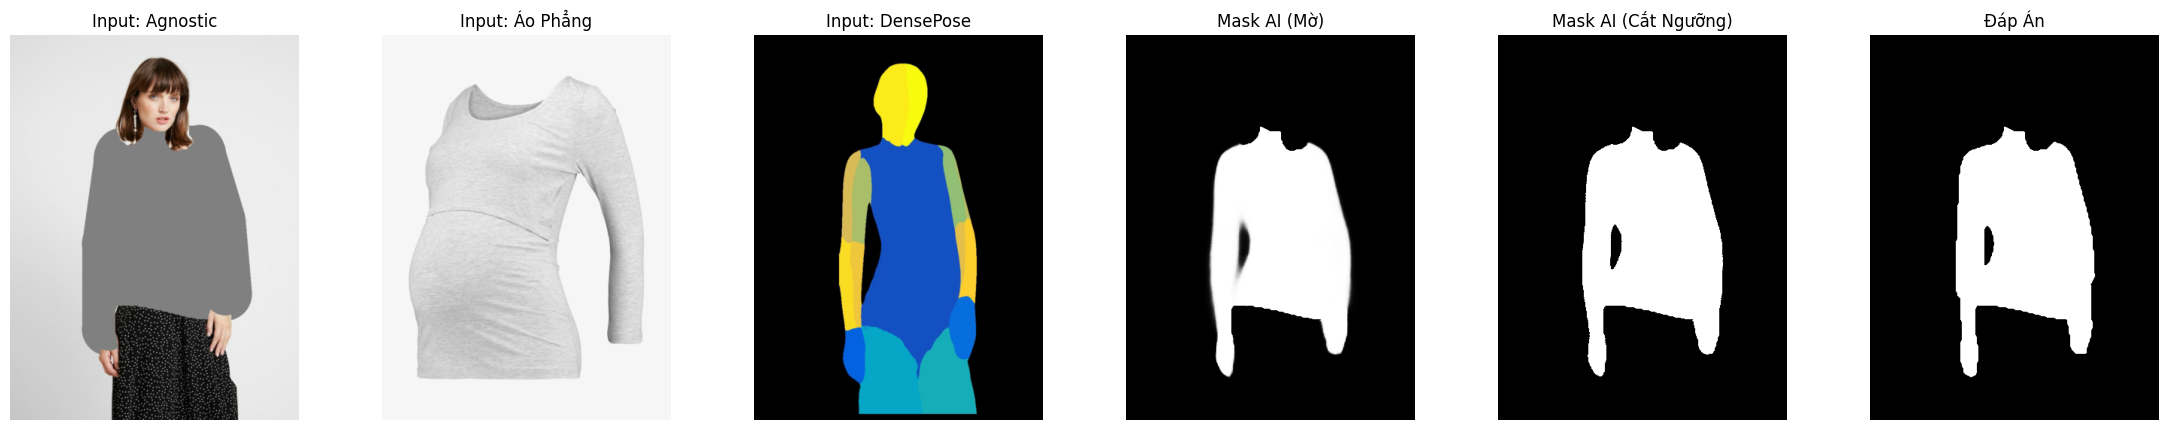


[PHÂN TÍCH FILE BEST & CHECKPOINT]
Đang phân tích cấu trúc file: /kaggle/input/datasets/pannguyeen/best-unet/unet_BEST_baseline.pth

--- DANH SÁCH 15 LỚP TRỌNG SỐ ĐẦU TIÊN (Tổng: 136) ---
Tên lớp: down1.double_conv.0.weight          | Kích thước: [32, 27, 3, 3]
Tên lớp: down1.double_conv.0.bias            | Kích thước: [32]
Tên lớp: down1.double_conv.1.weight          | Kích thước: [32]
Tên lớp: down1.double_conv.1.bias            | Kích thước: [32]
Tên lớp: down1.double_conv.1.running_mean    | Kích thước: [32]
Tên lớp: down1.double_conv.1.running_var     | Kích thước: [32]
Tên lớp: down1.double_conv.1.num_batches_tracked | Kích thước: []
Tên lớp: down1.double_conv.3.weight          | Kích thước: [32, 32, 3, 3]
Tên lớp: down1.double_conv.3.bias            | Kích thước: [32]
Tên lớp: down1.double_conv.4.weight          | Kích thước: [32]
Tên lớp: down1.double_conv.4.bias            | Kích thước: [32]
Tên lớp: down1.double_conv.4.running_mean    | Kích thước: [32]
Tên lớp: down1.double

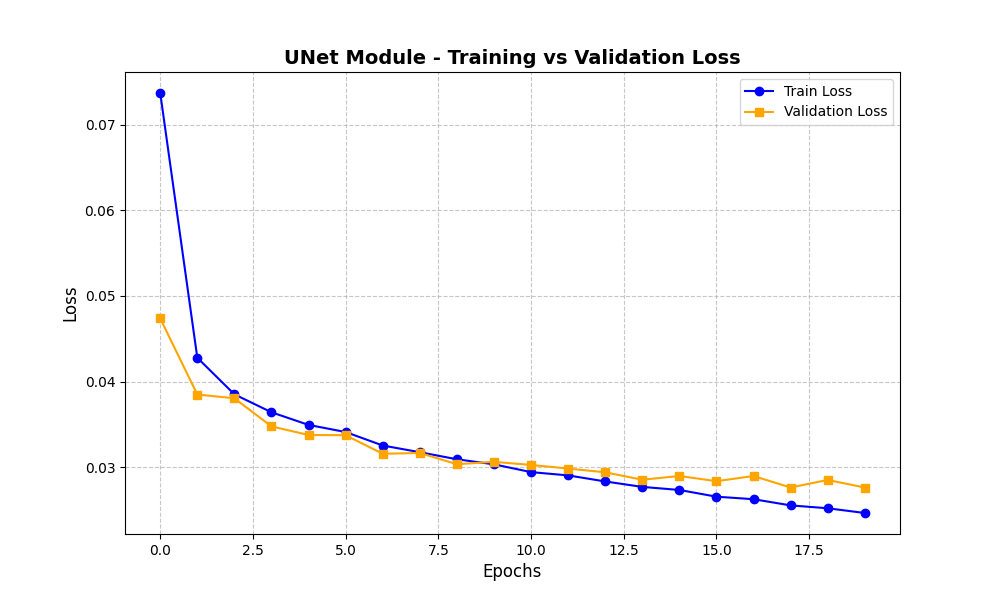

In [20]:
print("\n[1/4] HUẤN LUYỆN LIGHTWEIGHT UNET")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. KHỞI TẠO DATASET & LOADER (Giữ nguyên cấu hình)
unet_dataset_train = UNet_Pre_Dataset(processor=processor, image_paths=TRAIN_IMG_PATHS, is_train=True)
unet_dataset_val = UNet_Pre_Dataset(processor=processor, image_paths=VALID_IMG_PATHS, is_train=False)

unet_loader_train = DataLoader(unet_dataset_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2, pin_memory=False, prefetch_factor=1)
unet_loader_val = DataLoader(unet_dataset_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=False, prefetch_factor=1)

# 2. TÌM KIẾM MODEL ĐÃ TRAIN
best_path = None
search_patterns = ["/kaggle/working/unet_BEST_baseline.pth", "/kaggle/input/**/unet_BEST_baseline.pth"]

for pattern in search_patterns:
    found = glob.glob(pattern, recursive=True)
    if found:
        best_path = found[0]
        break

# 3. LUỒNG XỬ LÝ: TRAIN MỚI HOẶC NẠP MODEL CŨ
if best_path is None:
    print("\nBắt đầu huấn luyện U-Net")
    model_unet = trainLoopLightweightUNet(
        dataloader_train=unet_loader_train, 
        dataloader_val=unet_loader_val,
        num_epochs=NUM_EPOCHS_UNET, 
        learning_rate=LEARNING_RATE,
        patience=5,
        min_delta=1e-4
    )
    best_path = "/kaggle/working/unet_BEST_baseline.pth"
else:
    print(f"-> Phát hiện Model tại: {best_path}. Nạp Model...")
    model_unet = LightweightUNet(in_channels=27, out_channels=1).to(device)
    model_unet.load_state_dict(torch.load(best_path, map_location=device))
    model_unet.eval()

# 4. TRỰC QUAN HÓA & KIỂM TRA (Luôn chạy để bạn thấy kết quả)
print("\n[TRỰC QUAN MẶT NẠ DỰ ĐOÁN]")
with torch.no_grad():
    batch = next(iter(unet_loader_train))
    X, Y = batch['X'].to(device), batch['Y'].to(device)
    preds_raw = torch.sigmoid(model_unet(X))
    preds_sharp = (preds_raw > 0.5).float()
    
    # Hiển thị
    fig, axes = plt.subplots(1, 6, figsize=(28, 5))
    axes[0].imshow(tensor2np(X[0, :3, :, :])); axes[0].set_title("Input: Agnostic")
    axes[1].imshow(tensor2np(X[0, 21:24, :, :])); axes[1].set_title("Input: Áo Phẳng")
    axes[2].imshow(tensor2np(X[0, 24:, :, :])); axes[2].set_title("Input: DensePose")
    axes[3].imshow(preds_raw[0].squeeze().cpu().numpy(), cmap='gray'); axes[3].set_title("Mask AI (Mờ)")
    axes[4].imshow(preds_sharp[0].squeeze().cpu().numpy(), cmap='gray'); axes[4].set_title("Mask AI (Cắt Ngưỡng)")
    axes[5].imshow(Y[0].squeeze().cpu().numpy(), cmap='gray'); axes[5].set_title("Đáp Án")
    for ax in axes: ax.axis('off')
    plt.show()

# 5. BÁO CÁO PHÂN TÍCH (Lịch sử + Trọng số)
print("\n[PHÂN TÍCH FILE BEST & CHECKPOINT]")
if best_path is not None:
    print(f"Đang phân tích cấu trúc file: {best_path}\n")
    best_state_dict = torch.load(best_path, map_location='cpu')
    layers = list(best_state_dict.items())
    print(f"--- DANH SÁCH 15 LỚP TRỌNG SỐ ĐẦU TIÊN (Tổng: {len(layers)}) ---")
    for layer_name, weight_tensor in layers[:15]:
        print(f"Tên lớp: {layer_name:<35} | Kích thước: {list(weight_tensor.shape)}")
else:
    print("Không tìm thấy file unet_BEST_baseline.pth để phân tích trọng số.")

# 6. CHECKPOINT & CHART
checkpoint_paths = glob.glob("/kaggle/**/unet_checkpoint_baseline.pth", recursive=True)
if checkpoint_paths:
    checkpoint_data = torch.load(checkpoint_paths[0], map_location='cpu')
    train_history = checkpoint_data.get('history_train_loss', [])
    val_history = checkpoint_data.get('history_val_loss', [])
    print("\n--- CHI TIẾT LOSS ---")
    for i, (t, v) in enumerate(zip(train_history, val_history)):
        print(f"Epoch {i+1:02d} -> Train: {t:.6f} | Val: {v:.6f}")

chart_paths = glob.glob("/kaggle/**/unet_convergence_chart.png", recursive=True)
if chart_paths:
    display(IPyImage(filename=chart_paths[0], width=800))

In [21]:
print("BẮT ĐẦU SẢN XUẤT MẶT NẠ TỪ MẠNG U-NET...")

# 1. Khai báo thư mục xuất xưởng
UNET_MASK_OUT_DIR = Path("/kaggle/working/unet_predicted_masks")
UNET_MASK_OUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. KHỞI TẠO LẠI DATALOADER DÀNH RIÊNG CHO INFERENCE (RẤT QUAN TRỌNG)
# Tắt drop_last để không bỏ sót bất kỳ file nào, nhân đôi batch_size để chạy nhanh hơn (vì không cần tính gradient)
infer_loader_train = DataLoader(
    unet_dataset_train, 
    batch_size=BATCH_SIZE * 2, 
    shuffle=False,             
    drop_last=False,           
    num_workers=2
)

infer_loader_val = DataLoader(
    unet_dataset_val, 
    batch_size=BATCH_SIZE * 2, 
    shuffle=False, 
    drop_last=False, 
    num_workers=2
)

# 3. Hàm cốt lõi: Quét DataLoader và lưu ảnh
def generate_and_save_masks(dataloader, desc_text):
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc_text):
            X = batch['X'].to(device)
            
            # Chốt chặn an toàn: Bắt lỗi nếu class Dataset thiếu key 'Filename'
            if 'Filename' not in batch:
                raise KeyError("LỖI: Class UNet_Pre_Dataset của bạn chưa trả về 'Filename'. Hãy cuộn lên hàm __getitem__ của UNet_Pre_Dataset, thêm dòng: 'Filename': Path(self.image_paths[idx]).name")
                
            filenames = batch['Filename']
            
            with torch.amp.autocast('cuda'):
                # Sinh mask
                preds_raw = torch.sigmoid(model_unet(X))
                # Ép ngưỡng nhị phân để viền mặt nạ sắc lẹm
                preds_sharp = (preds_raw > 0.5).float()
            
            # Lưu ảnh ra thư mục
            for i in range(preds_sharp.size(0)):
                filename = filenames[i]
                mask_tensor = preds_sharp[i]
                save_image(mask_tensor, UNET_MASK_OUT_DIR / filename)

# 4. Thực thi sản xuất
print("\n=> Đang xử lý tập Train...")
generate_and_save_masks(infer_loader_train, "U-Net Infer Train")

print("\n=> Đang xử lý tập Valid...")
generate_and_save_masks(infer_loader_val, "U-Net Infer Valid")

print(f"\nHOÀN THÀNH! Toàn bộ mặt nạ đã sẵn sàng tại: {UNET_MASK_OUT_DIR}")

BẮT ĐẦU SẢN XUẤT MẶT NẠ TỪ MẠNG U-NET...

=> Đang xử lý tập Train...


U-Net Infer Train: 100%|██████████| 506/506 [13:54<00:00,  1.65s/it]



=> Đang xử lý tập Valid...


U-Net Infer Valid: 100%|██████████| 90/90 [02:06<00:00,  1.40s/it]


HOÀN THÀNH! Toàn bộ mặt nạ đã sẵn sàng tại: /kaggle/working/unet_predicted_masks


## 3. Lightweight GMM (Bao gồm GMM và Warp Cloth)


[2/4] HUẤN LUYỆN LIGHTWEIGHT GMM
-> Phát hiện Model tại: /kaggle/input/datasets/hodangthanhphat/gmm-best-new/gmm_ultimate_BEST.pth. Nạp trọng số...
-> Nạp trọng số thành công.

[KIỂM TRA TRỰC QUAN MODULE GMM]


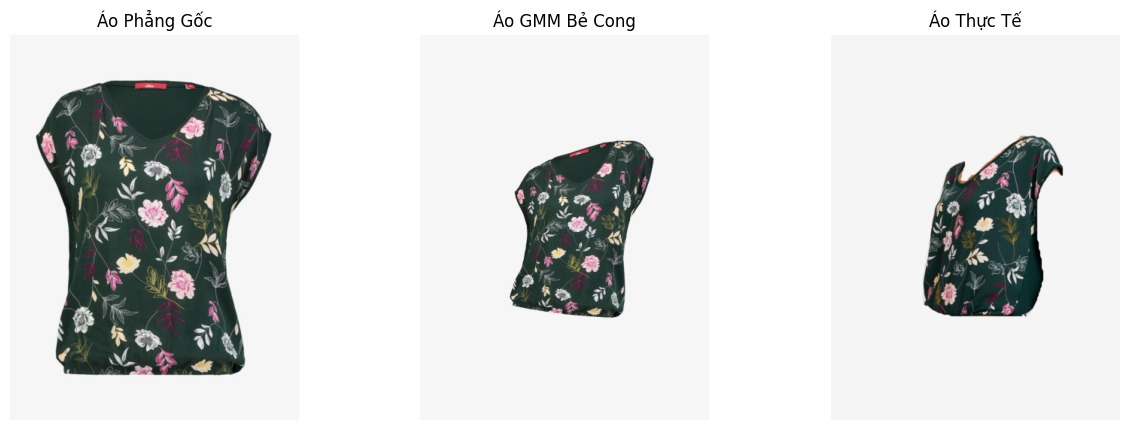


[4/5] TRÍCH XUẤT LỊCH SỬ HỌC TỪ: /kaggle/input/datasets/hodangthanhphat/gmm-best-new/gmm_checkpoint_resume.pth
--- CHI TIẾT LOSS THEO TỪNG EPOCH ---
Epoch 01 -> Train Loss: 0.098865 | Val Loss: 0.075969
Epoch 02 -> Train Loss: 0.069543 | Val Loss: 0.067121
Epoch 03 -> Train Loss: 0.063859 | Val Loss: 0.064162
Epoch 04 -> Train Loss: 0.061068 | Val Loss: 0.062663
Epoch 05 -> Train Loss: 0.058940 | Val Loss: 0.061403
Epoch 06 -> Train Loss: 0.057057 | Val Loss: 0.061520
Epoch 07 -> Train Loss: 0.055476 | Val Loss: 0.060323
Epoch 08 -> Train Loss: 0.053901 | Val Loss: 0.061350
Epoch 09 -> Train Loss: 0.052425 | Val Loss: 0.059774
Epoch 10 -> Train Loss: 0.051344 | Val Loss: 0.059648
Epoch 11 -> Train Loss: 0.050386 | Val Loss: 0.058754
Epoch 12 -> Train Loss: 0.049659 | Val Loss: 0.058562
Epoch 13 -> Train Loss: 0.048773 | Val Loss: 0.059400
Epoch 14 -> Train Loss: 0.048087 | Val Loss: 0.057738
Epoch 15 -> Train Loss: 0.047429 | Val Loss: 0.058206

[5/5] HIỂN THỊ BIỂU ĐỒ TỪ: /kaggle/inpu

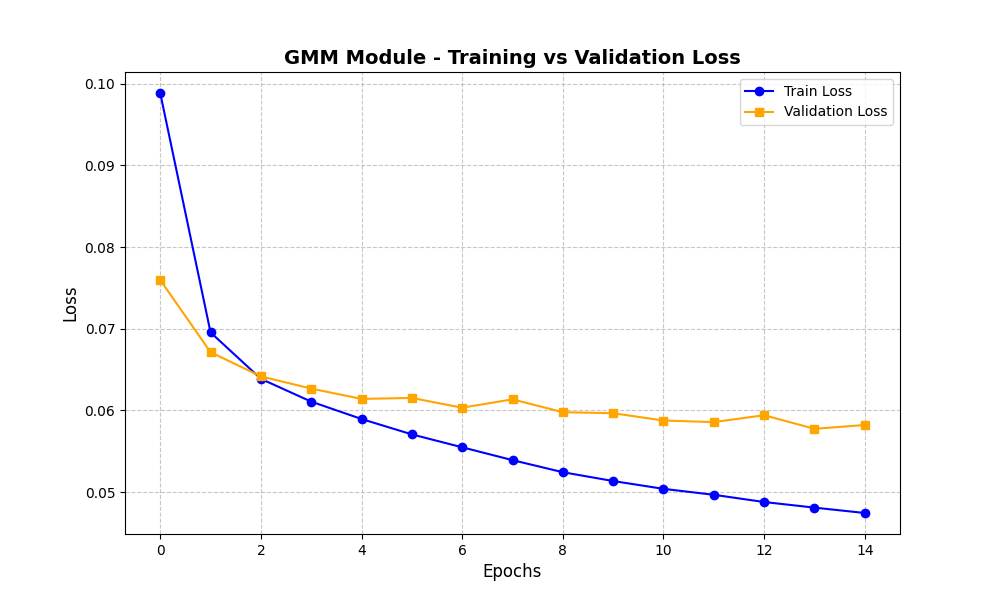

In [22]:
print("\n[2/4] HUẤN LUYỆN LIGHTWEIGHT GMM")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. KHỞI TẠO DATASET & LOADER
gmm_dataset_train = GMM_Pre_Dataset(processor, TRAIN_IMG_PATHS)
gmm_dataset_val = GMM_Pre_Dataset(processor, VALID_IMG_PATHS)

gmm_loader_train = DataLoader(
    gmm_dataset_train, batch_size=BATCH_SIZE, shuffle=True, 
    drop_last=True, num_workers=2, pin_memory=False, prefetch_factor=1
)
gmm_loader_val = DataLoader(
    gmm_dataset_val, batch_size=BATCH_SIZE, shuffle=False, 
    num_workers=2, pin_memory=False, prefetch_factor=1
)

# 2. TÌM KIẾM MODEL ĐÃ TRAIN
gmm_path = None
search_patterns = [
    "/kaggle/working/gmm_ultimate_BEST.pth",
    "/kaggle/input/**/gmm_ultimate_BEST.pth"
]

for pattern in search_patterns:
    found = glob.glob(pattern, recursive=True)
    if found:
        gmm_path = found[0]
        break

# 3. LUỒNG XỬ LÝ: TRAIN MỚI HOẶC NẠP MODEL CŨ
if gmm_path is None:
    print("\nBắt đầu huấn luyện")
    model_gmm = trainLoopLightweightGMM(
        dataloader_train=gmm_loader_train, 
        dataloader_val=gmm_loader_val,
        num_epochs=NUM_EPOCHS_GMM, 
        learning_rate=1e-5,
        patience=5, 
        min_delta=1e-5
    )
    gmm_path = "/kaggle/working/gmm_ultimate_BEST.pth"
else:
    print(f"-> Phát hiện Model tại: {gmm_path}. Nạp trọng số...")
    model_gmm = LightweightGMM(grid_size=5).to(device)
    checkpoint = torch.load(gmm_path, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model_gmm.load_state_dict(checkpoint['model_state_dict'])
    else:
        model_gmm.load_state_dict(checkpoint)
    model_gmm.eval()
    print("-> Nạp trọng số thành công.")

# 4. TRỰC QUAN HÓA & BÁO CÁO
print("\n[KIỂM TRA TRỰC QUAN MODULE GMM]")
tps_generator = TPSGridGen(target_H=512, target_W=384, grid_size=5).to(device)

with torch.no_grad():
    batch = next(iter(gmm_loader_train))
    cloth, agnostic, pose, gt_cloth = batch['Cloth'].to(device), batch['Agnostic'].to(device), batch['Pose'].to(device), batch['Target'].to(device)
    
    theta = model_gmm(cloth, agnostic, pose)
    grid = tps_generator(theta)
    warped_cloth = F.grid_sample(cloth, grid, padding_mode='border', align_corners=True)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(tensor2np(cloth[0])); axes[0].set_title("Áo Phẳng Gốc")
    axes[1].imshow(tensor2np(warped_cloth[0])); axes[1].set_title("Áo GMM Bẻ Cong")
    axes[2].imshow(tensor2np(gt_cloth[0])); axes[2].set_title("Áo Thực Tế")
    for ax in axes: ax.axis('off')
    plt.show()

# 5. ĐỌC FILE CHECKPOINT
checkpoint_paths = glob.glob("/kaggle/**/gmm_checkpoint_resume.pth", recursive=True)

if len(checkpoint_paths) > 0:
    print(f"\n[4/5] TRÍCH XUẤT LỊCH SỬ HỌC TỪ: {checkpoint_paths[0]}")
    checkpoint_data = torch.load(checkpoint_paths[0], map_location='cpu')
    
    train_history = checkpoint_data.get('history_train_loss', [])
    val_history = checkpoint_data.get('history_val_loss', [])
    
    if len(train_history) > 0 and len(val_history) > 0:
        print("--- CHI TIẾT LOSS THEO TỪNG EPOCH ---")
        for i, (t_loss, v_loss) in enumerate(zip(train_history, val_history)):
            print(f"Epoch {i+1:02d} -> Train Loss: {t_loss:.6f} | Val Loss: {v_loss:.6f}")
    else:
        print("File checkpoint tồn tại nhưng không chứa mảng lịch sử (history_loss).")
else:
    print("\n[4/5] Không tìm thấy file gmm_checkpoint_resume.pth.")

# 6. HIỂN THỊ BIỂU ĐỒ HỘI TỤ
chart_paths = glob.glob("/kaggle/**/gmm_convergence_chart.png", recursive=True)

if len(chart_paths) > 0:
    print(f"\n[5/5] HIỂN THỊ BIỂU ĐỒ TỪ: {chart_paths[0]}")
    display(IPyImage(filename=chart_paths[0], width=800))
else:
    print("\n[5/5] Không tìm thấy file ảnh biểu đồ của GMM.")


SẢN XUẤT ÁO BẺ CONG (GMM) & MẶT NẠ]
-> Dữ liệu chưa đủ (Áo: 0, Mask: 0 / Tổng 10516). Bắt đầu sản xuất...
  -> Đã sản xuất 400/10516 áo và mask...
  -> Đã sản xuất 800/10516 áo và mask...
  -> Đã sản xuất 1200/10516 áo và mask...
  -> Đã sản xuất 1600/10516 áo và mask...
  -> Đã sản xuất 2000/10516 áo và mask...
  -> Đã sản xuất 2400/10516 áo và mask...
  -> Đã sản xuất 2800/10516 áo và mask...
  -> Đã sản xuất 3200/10516 áo và mask...
  -> Đã sản xuất 3600/10516 áo và mask...
  -> Đã sản xuất 4000/10516 áo và mask...
  -> Đã sản xuất 4400/10516 áo và mask...
  -> Đã sản xuất 4800/10516 áo và mask...
  -> Đã sản xuất 5200/10516 áo và mask...
  -> Đã sản xuất 5600/10516 áo và mask...
  -> Đã sản xuất 6000/10516 áo và mask...
  -> Đã sản xuất 6400/10516 áo và mask...
  -> Đã sản xuất 6800/10516 áo và mask...
  -> Đã sản xuất 7200/10516 áo và mask...
  -> Đã sản xuất 7600/10516 áo và mask...
  -> Đã sản xuất 8000/10516 áo và mask...
  -> Đã sản xuất 8400/10516 áo và mask...
  -> Đã sản x

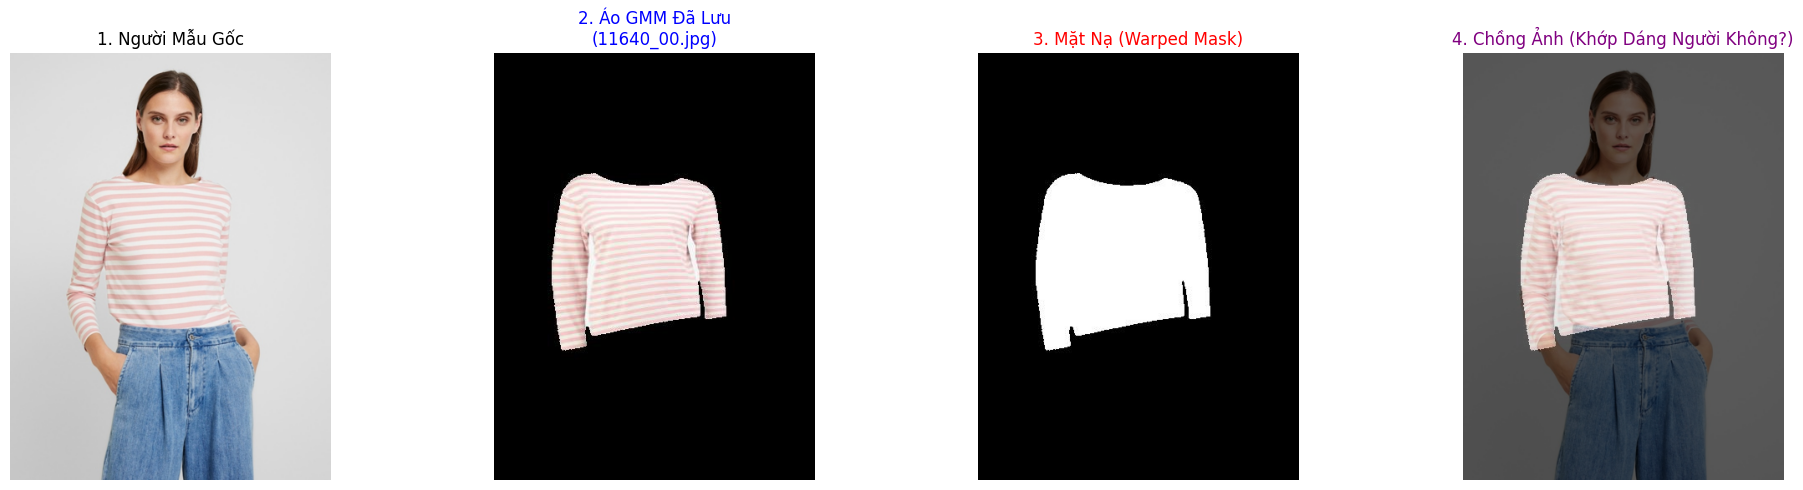

In [23]:
print("\nSẢN XUẤT ÁO BẺ CONG (GMM) & MẶT NẠ]")

# 1. KHAI BÁO THƯ MỤC VÀ TẠO MỚI NẾU CHƯA CÓ
WARPED_OUT_DIR = Path("/kaggle/working/warped_cloths")
WARPED_MASK_OUT_DIR = Path("/kaggle/working/warped_masks")
WARPED_OUT_DIR.mkdir(parents=True, exist_ok=True)
WARPED_MASK_OUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. KIỂM TRA LOGIC TỒN TẠI (SKIP SẢN XUẤT)
total_targets = len(TARGET_IMG_PATHS)
warped_cloths_count = len(list(WARPED_OUT_DIR.glob("*.jpg")))
warped_masks_count = len(list(WARPED_MASK_OUT_DIR.glob("*.jpg")))

if warped_cloths_count == total_targets and warped_masks_count == total_targets:
    print(f">> Dữ liệu bẻ cong đã hoàn thiện ({warped_cloths_count}/{total_targets}). Bỏ qua bước sản xuất!")
else:
    print(f"-> Dữ liệu chưa đủ (Áo: {warped_cloths_count}, Mask: {warped_masks_count} / Tổng {total_targets}). Bắt đầu sản xuất...")
    
    # Kích hoạt Model (model_gmm phải được nạp trọng số từ cell trước)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_gmm.eval()
    tps_generator = TPSGridGen(target_H=512, target_W=384, grid_size=5).to(device)

    inference_dataset = GMM_Pre_Dataset(processor, TARGET_IMG_PATHS)
    inference_loader = DataLoader(
        inference_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True
    )

    with torch.no_grad():
        for step, batch in enumerate(inference_loader):
            cloth = batch['Cloth'].to(device)
            agnostic = batch['Agnostic'].to(device)
            pose = batch['Pose'].to(device)
            c_mask = batch['Cloth_Mask'].to(device) 
            filenames = batch['Filename']
            
            # Tính lưới bẻ cong
            theta = model_gmm(cloth, agnostic, pose)
            grid = tps_generator(theta)
            
            # Bẻ cong
            with torch.amp.autocast('cuda'):
                warped_cloth = F.grid_sample(cloth, grid, padding_mode='border', align_corners=True)
                warped_mask = F.grid_sample(c_mask, grid, padding_mode='zeros', align_corners=True)

            # Ép nhị phân và lọc nền đen
            warped_mask_binary = (warped_mask > 0.5).float()
            final_warped_cloth = warped_cloth * warped_mask_binary + (-1.0) * (1.0 - warped_mask_binary)
            
            # LƯU FILE
            for i in range(final_warped_cloth.size(0)):
                # Dịch từ dải [-1, 1] sang [0, 1] cho áo RGB
                w_cloth_norm = (final_warped_cloth[i] + 1.0) / 2.0 
                
                save_image(w_cloth_norm, WARPED_OUT_DIR / filenames[i])
                save_image(warped_mask_binary[i], WARPED_MASK_OUT_DIR / filenames[i])

            if (step + 1) % 50 == 0:
                print(f"  -> Đã sản xuất {(step + 1) * BATCH_SIZE}/{total_targets} áo và mask...")
                
    print("-> Hoàn thành sản xuất và lưu dữ liệu bẻ cong!")

# 3. TRỰC QUAN HÓA KIỂM TRA (Luôn chạy)
print("\n[ĐANG KIỂM TRA CHẤT LƯỢNG ÁO & MẶT NẠ VỪA LƯU]")

all_warped_files = list(WARPED_OUT_DIR.glob("*.jpg"))

if len(all_warped_files) > 0:
    sample_file = random.choice(all_warped_files)
    filename = sample_file.name
    
    # Tìm ảnh gốc
    orig_img_path = TRAIN_DIR / 'image' / filename
    if not orig_img_path.exists():
        orig_img_path = TEST_DIR / 'image' / filename
        
    person_img = Image.open(orig_img_path).resize((384, 512))
    warped_img = Image.open(sample_file).resize((384, 512))
    
    # Đọc mask
    mask_path = WARPED_MASK_OUT_DIR / filename
    if mask_path.exists():
        warped_mask_img = Image.open(mask_path).resize((384, 512))
    else:
        print(f"Cảnh báo: Không tìm thấy mặt nạ cho {filename}")
        warped_mask_img = Image.new('L', (384, 512), 0) 
        
    # Chồng ảnh (Blend)
    overlay = Image.blend(person_img.convert('RGBA'), warped_img.convert('RGBA'), alpha=0.6)
    
    # Hiển thị
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(person_img); axes[0].set_title("1. Người Mẫu Gốc")
    axes[1].imshow(warped_img); axes[1].set_title(f"2. Áo GMM Đã Lưu\n({filename})", color='blue')
    axes[2].imshow(warped_mask_img, cmap='gray'); axes[2].set_title("3. Mặt Nạ (Warped Mask)", color='red')
    axes[3].imshow(overlay); axes[3].set_title("4. Chồng Ảnh (Khớp Dáng Người Không?)", color='purple')
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy file ảnh nào trong thư mục xuất áo bẻ cong!")

## 4. TOM


[3/4] HUẤN LUYỆN TOM - ABLATION STUDY
Đang lọc dữ liệu hợp lệ cho module TOM...
-> Dữ liệu hợp lệ: 8092 Train | 1428 Valid

==================== CẤU HÌNH: Baseline_No_Dropout ====================
>> BỎ QUA TRAINING. Đang nạp Model từ: /kaggle/input/datasets/hodangthanhphat/tom-no-dropout/tom_BEST_Baseline_No_Dropout.pth
-> Đang tải biểu đồ hội tụ từ: /kaggle/input/datasets/hodangthanhphat/tom-no-dropout/tom_convergence_chart_Baseline_No_Dropout.png


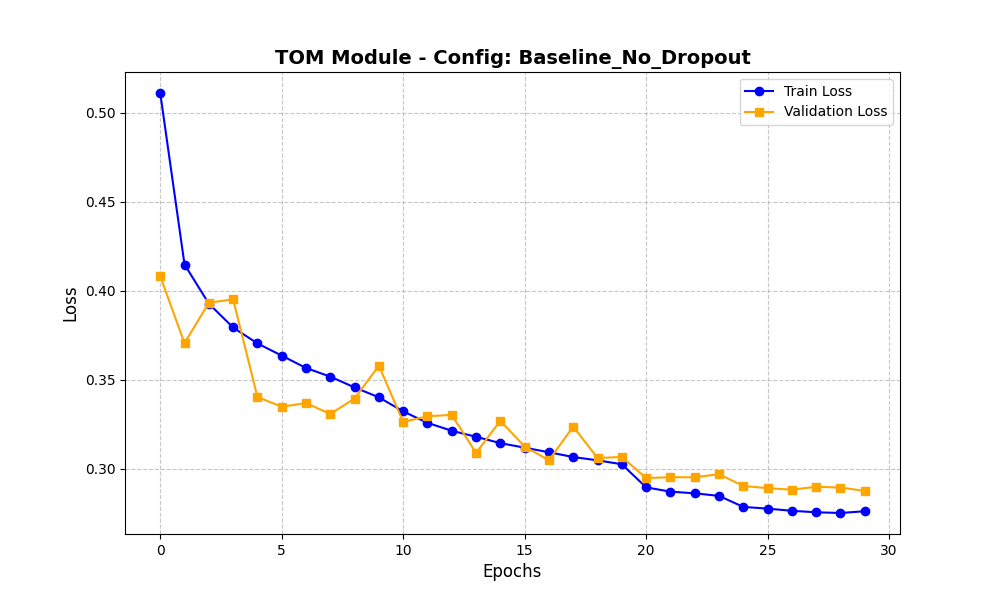


==================== CẤU HÌNH: With_Dropout_0.3 ====================
>> BỎ QUA TRAINING. Đang nạp Model từ: /kaggle/input/datasets/hodangthanhphat/tom-dropout-03-best/tom_BEST_With_Dropout_0.3.pth
-> Đang tải biểu đồ hội tụ từ: /kaggle/input/datasets/hodangthanhphat/tom-dropout-03-best/tom_convergence_chart_With_Dropout_0.3.png


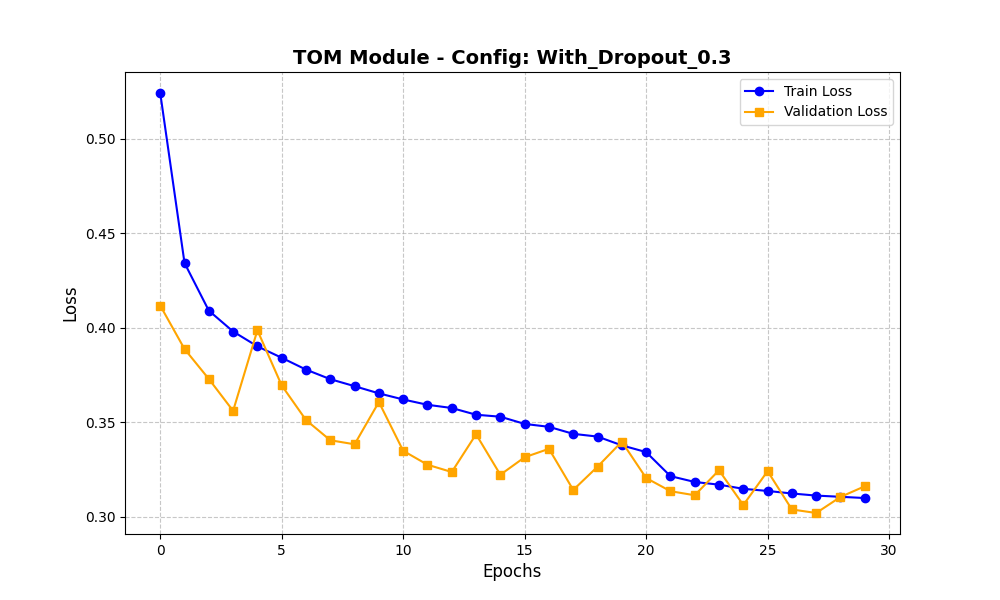


==================== CẤU HÌNH: Low_LR_5e_5 ====================
>> BỎ QUA TRAINING. Đang nạp Model từ: /kaggle/input/datasets/hodangthanhphat/tom-lowlr-best/tom_BEST_Low_LR_5e_5.pth
-> Đang tải biểu đồ hội tụ từ: /kaggle/input/datasets/hodangthanhphat/tom-lowlr-best/tom_convergence_chart_Low_LR_5e_5.png


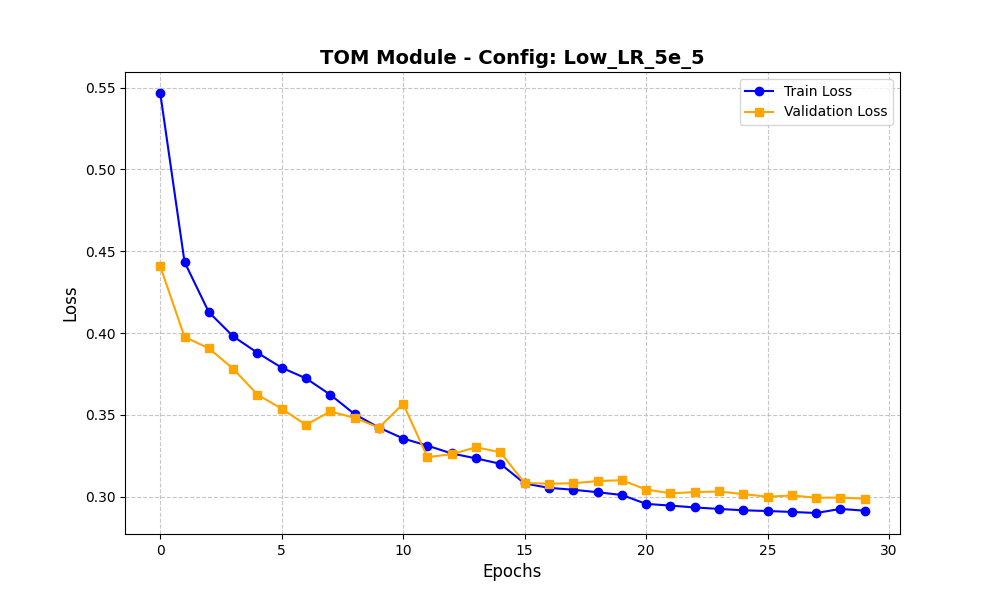


==================== CẤU HÌNH: High_LR_5e_4 ====================
>> Đang khởi tạo DataLoader để Huấn Luyện...
HUẤN LUYỆN MODULE 2 (TOM) TRÊN cuda...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 217MB/s]



[PHÁT HIỆN CHECKPOINT] Đang khôi phục từ /kaggle/input/datasets/hodangthanhphat/tom-cp-highlr/tom_checkpoint_High_LR_5e_4.pth...
-> Khôi phục thành công! Chạy tiếp từ Epoch 13.



TOM Epoch 13/30 [Train]: 100%|██████████| 1011/1011 [14:45<00:00,  1.14it/s, Loss=0.4058]


-> Kết thúc Epoch 13 | Train Loss: 0.325405 | Val Loss: 0.316028 | LR: 0.000500
Val Loss không cải thiện. Cảnh báo dừng sớm: 1/5



TOM Epoch 14/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.3111]


-> Kết thúc Epoch 14 | Train Loss: 0.321278 | Val Loss: 0.305447 | LR: 0.000500
Val Loss giảm từ 0.308256 xuống 0.305447.
-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...



TOM Epoch 15/30 [Train]: 100%|██████████| 1011/1011 [14:41<00:00,  1.15it/s, Loss=0.2830]


-> Kết thúc Epoch 15 | Train Loss: 0.317195 | Val Loss: 0.299637 | LR: 0.000500
Đang trực quan kết quả Epoch 15...


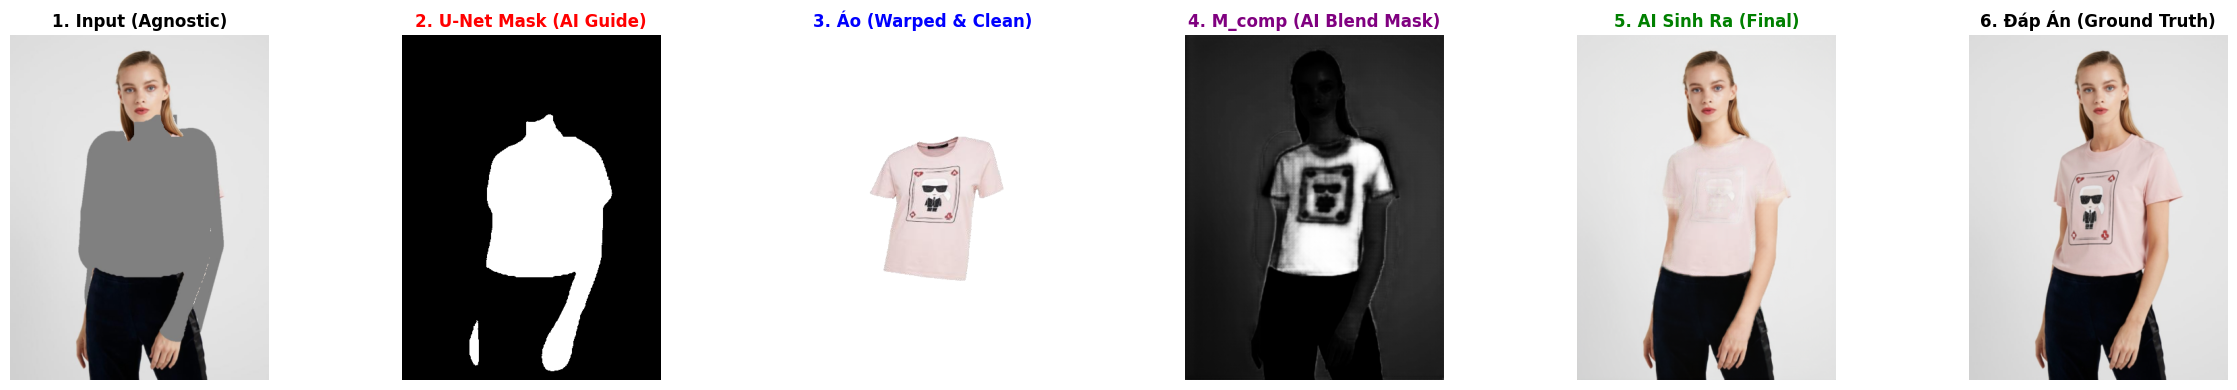

Val Loss giảm từ 0.305447 xuống 0.299637.
-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...



TOM Epoch 16/30 [Train]: 100%|██████████| 1011/1011 [14:41<00:00,  1.15it/s, Loss=0.3045]


-> Kết thúc Epoch 16 | Train Loss: 0.311324 | Val Loss: 0.310108 | LR: 0.000500
Val Loss không cải thiện. Cảnh báo dừng sớm: 1/5



TOM Epoch 17/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.3099]


-> Kết thúc Epoch 17 | Train Loss: 0.305031 | Val Loss: 0.332228 | LR: 0.000500
Val Loss không cải thiện. Cảnh báo dừng sớm: 2/5



...

-> Kết thúc Epoch 18 | Train Loss: 0.301109 | Val Loss: 0.300224 | LR: 0.000250
Val Loss không cải thiện. Cảnh báo dừng sớm: 3/5



TOM Epoch 19/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.2944]


-> Kết thúc Epoch 19 | Train Loss: 0.285494 | Val Loss: 0.298167 | LR: 0.000250
Val Loss giảm từ 0.299637 xuống 0.298167.
-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...



TOM Epoch 20/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.2965]


-> Kết thúc Epoch 20 | Train Loss: 0.282987 | Val Loss: 0.286483 | LR: 0.000250
Đang trực quan kết quả Epoch 20...


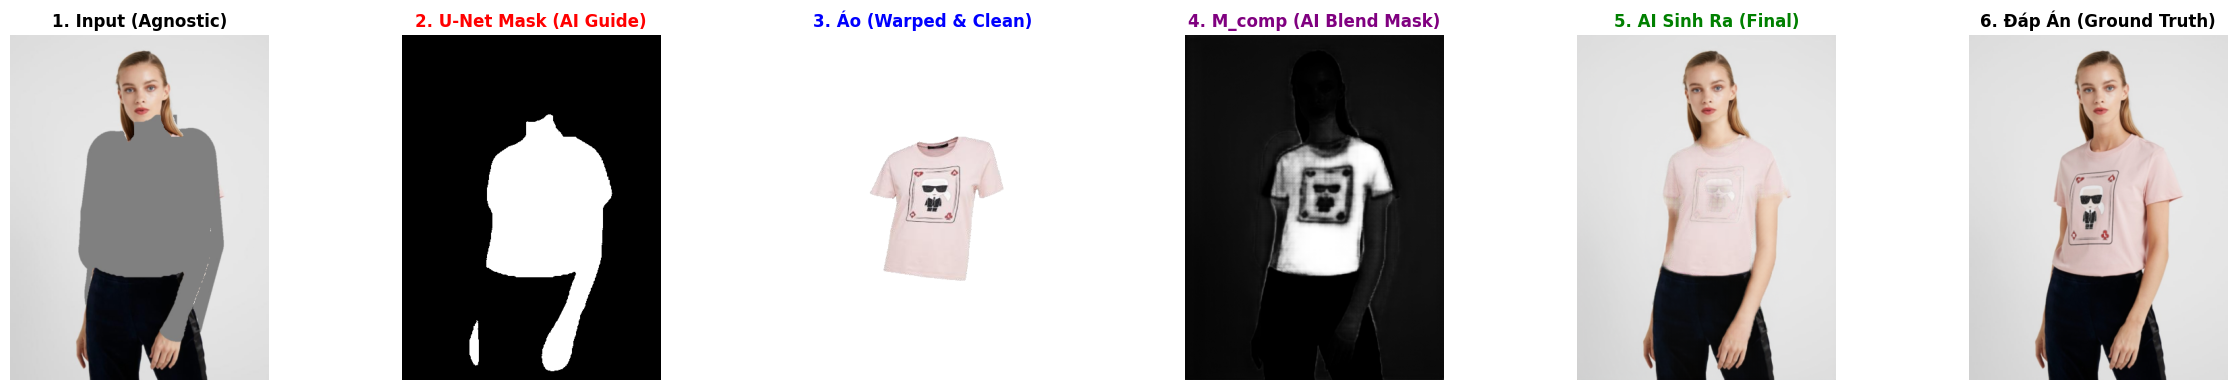

Val Loss giảm từ 0.298167 xuống 0.286483.
-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...



TOM Epoch 21/30 [Train]: 100%|██████████| 1011/1011 [14:43<00:00,  1.14it/s, Loss=0.2854]


-> Kết thúc Epoch 21 | Train Loss: 0.281419 | Val Loss: 0.297152 | LR: 0.000250
Val Loss không cải thiện. Cảnh báo dừng sớm: 1/5



TOM Epoch 22/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.2849]


-> Kết thúc Epoch 22 | Train Loss: 0.280181 | Val Loss: 0.292612 | LR: 0.000250
Val Loss không cải thiện. Cảnh báo dừng sớm: 2/5



...

-> Kết thúc Epoch 23 | Train Loss: 0.278765 | Val Loss: 0.291875 | LR: 0.000125
Val Loss không cải thiện. Cảnh báo dừng sớm: 3/5



TOM Epoch 24/30 [Train]: 100%|██████████| 1011/1011 [14:41<00:00,  1.15it/s, Loss=0.3270]


-> Kết thúc Epoch 24 | Train Loss: 0.270680 | Val Loss: 0.280409 | LR: 0.000125
Val Loss giảm từ 0.286483 xuống 0.280409.
-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...



TOM Epoch 25/30 [Train]: 100%|██████████| 1011/1011 [14:43<00:00,  1.14it/s, Loss=0.2704]


-> Kết thúc Epoch 25 | Train Loss: 0.270127 | Val Loss: 0.279588 | LR: 0.000125
Đang trực quan kết quả Epoch 25...


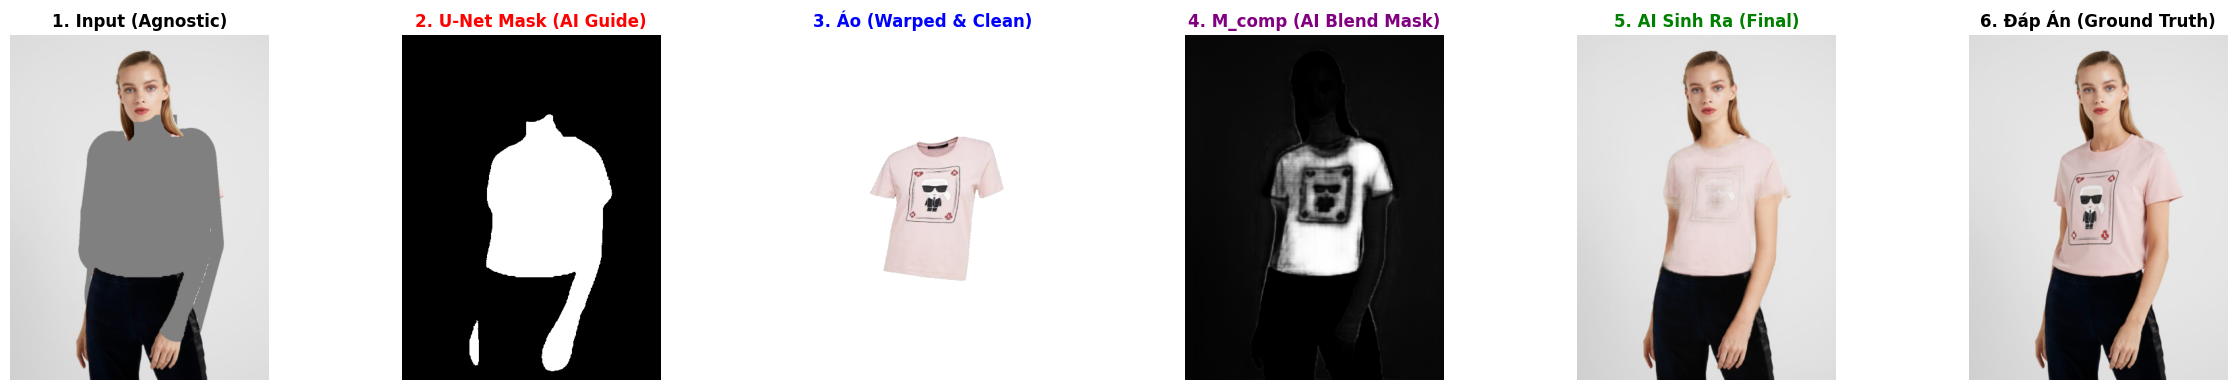

Val Loss giảm từ 0.280409 xuống 0.279588.
-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...



TOM Epoch 26/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.2869]


-> Kết thúc Epoch 26 | Train Loss: 0.269354 | Val Loss: 0.279682 | LR: 0.000125
Val Loss không cải thiện. Cảnh báo dừng sớm: 1/5



TOM Epoch 27/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.3028]


-> Kết thúc Epoch 27 | Train Loss: 0.268516 | Val Loss: 0.281481 | LR: 0.000125
Val Loss không cải thiện. Cảnh báo dừng sớm: 2/5



...

-> Kết thúc Epoch 28 | Train Loss: 0.267985 | Val Loss: 0.279340 | LR: 0.000125
Val Loss giảm từ 0.279588 xuống 0.279340.
-> Đang lưu lại trọng số và bộ siêu tham số tốt nhất...



TOM Epoch 29/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.2433]


-> Kết thúc Epoch 29 | Train Loss: 0.267274 | Val Loss: 0.281983 | LR: 0.000125
Val Loss không cải thiện. Cảnh báo dừng sớm: 1/5



TOM Epoch 30/30 [Train]: 100%|██████████| 1011/1011 [14:42<00:00,  1.15it/s, Loss=0.2781]


-> Kết thúc Epoch 30 | Train Loss: 0.266874 | Val Loss: 0.279621 | LR: 0.000125
Đang trực quan kết quả Epoch 30...


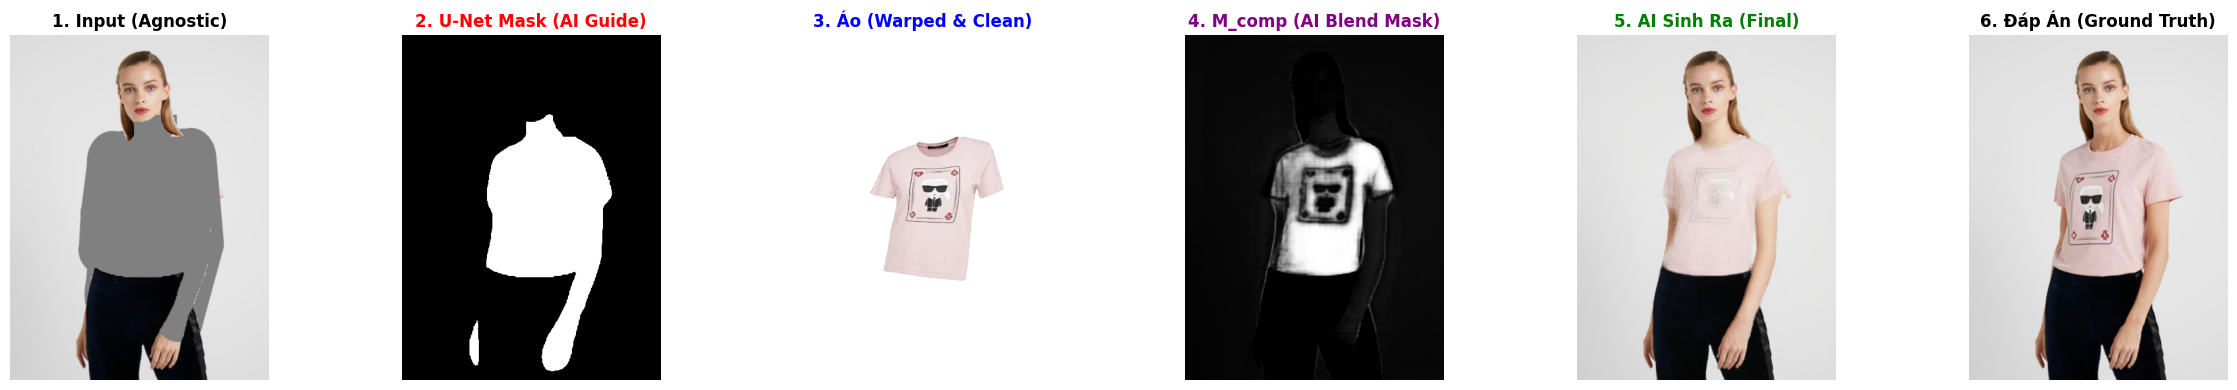

Val Loss không cải thiện. Cảnh báo dừng sớm: 2/5


HOÀN THÀNH HUẤN LUYỆN MODULE 2 (TOM)!
Kỷ lục Val Loss: 0.279340
-> Đã lưu biểu đồ hội tụ tại: /kaggle/working/tom_convergence_chart_High_LR_5e_4.png


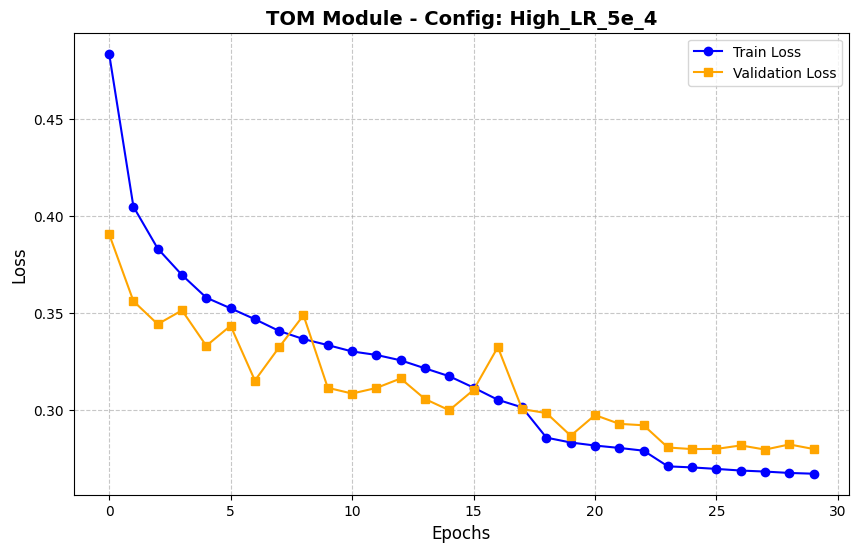


=> KẾT QUẢ ABLATION STUDY:
   + Baseline_No_Dropout: Val L1 Loss = 0.287688
   + With_Dropout_0.3: Val L1 Loss = 0.302006
   + Low_LR_5e_5: Val L1 Loss = 0.298784
   + High_LR_5e_4: Val L1 Loss = 0.279340

=> Đang lưu bản Final có thông số tốt nhất...

[ĐANG XUẤT ẢNH TRỰC QUAN]


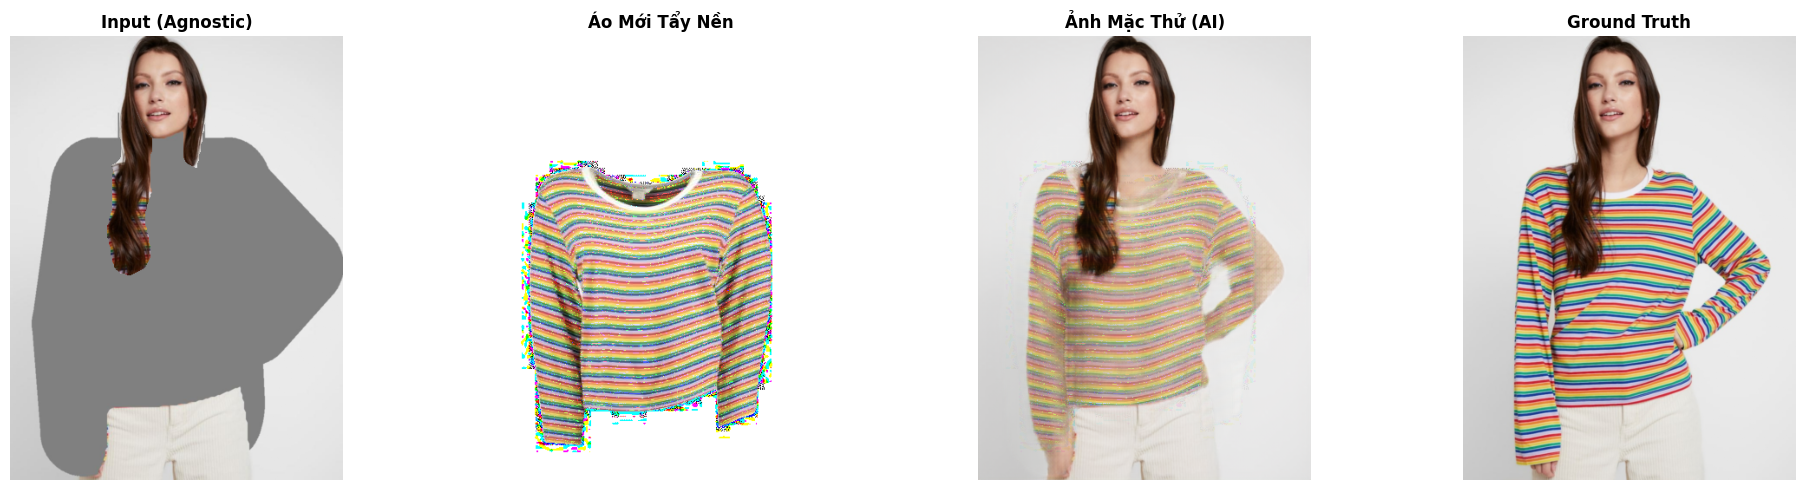

In [24]:
print("\n[3/4] HUẤN LUYỆN TOM - ABLATION STUDY")

device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device_type)

print("Đang lọc dữ liệu hợp lệ cho module TOM...")
UNET_MASK_OUT_DIR = Path("/kaggle/working/unet_predicted_masks")
WARPED_MASK_OUT_DIR = Path("/kaggle/working/warped_masks")

FINAL_TRAIN_PATHS = filter_valid_paths(TRAIN_IMG_PATHS, WARPED_OUT_DIR, WARPED_MASK_OUT_DIR, UNET_MASK_OUT_DIR)
FINAL_VALID_PATHS = filter_valid_paths(VALID_IMG_PATHS, WARPED_OUT_DIR, WARPED_MASK_OUT_DIR, UNET_MASK_OUT_DIR)
print(f"-> Dữ liệu hợp lệ: {len(FINAL_TRAIN_PATHS)} Train | {len(FINAL_VALID_PATHS)} Valid")

if not FINAL_TRAIN_PATHS:
    raise RuntimeError("Lỗi: Không đủ dữ liệu Train hợp lệ.")

train_dataset = TOM_Pre_Dataset(processor, FINAL_TRAIN_PATHS, WARPED_OUT_DIR, WARPED_MASK_OUT_DIR, UNET_MASK_OUT_DIR, is_train=True)
valid_dataset = TOM_Pre_Dataset(processor, FINAL_VALID_PATHS, WARPED_OUT_DIR, WARPED_MASK_OUT_DIR, UNET_MASK_OUT_DIR, is_train=False)

ablation_configs = [
    {'lr': 1e-4, 'batch_size': BATCH_SIZE, 'dropout': 0.0, 'name': 'Baseline_No_Dropout'},
    {'lr': 1e-4, 'batch_size': BATCH_SIZE, 'dropout': 0.3, 'name': 'With_Dropout_0.3'},
    {'lr': 5e-5, 'batch_size': BATCH_SIZE, 'dropout': 0.0, 'name': 'Low_LR_5e_5'},
    {'lr': 5e-4, 'batch_size': BATCH_SIZE, 'dropout': 0.0, 'name': 'High_LR_5e_4'}
]

ablation_results = {}
best_model_overall = None
best_loss_overall = float('inf')

def is_training_complete(ckpt_path, patience=5, num_epochs=NUM_EPOCHS_TOM):
    if not ckpt_path: return False
    ckpt = torch.load(ckpt_path, map_location='cpu')
    last_epoch = ckpt.get('epoch', 0)
    if last_epoch >= num_epochs - 1: return True
    
    val_history = ckpt.get('history_val_loss', [])
    if len(val_history) > patience:
        best_val_idx = val_history.index(min(val_history))
        if (len(val_history) - 1 - best_val_idx) >= patience: return True
    return False

for config in ablation_configs:
    print(f"\n{'='*20} CẤU HÌNH: {config['name']} {'='*20}")
    
    c_name = config['name']
    best_model_path = next(iter(glob.glob(f"/kaggle/**/tom_BEST_{c_name}.pth", recursive=True)), None)
    best_hyper_path = next(iter(glob.glob(f"/kaggle/**/tom_best_hyperparameters_{c_name}.json", recursive=True)), None)
    checkpoint_path = next(iter(glob.glob(f"/kaggle/**/tom_checkpoint_{c_name}.pth", recursive=True)), None)
    chart_path = next(iter(glob.glob(f"/kaggle/**/tom_convergence_chart_{c_name}.png", recursive=True)), None)
    is_fully_completed = bool(best_model_path and best_hyper_path and is_training_complete(checkpoint_path))

    if is_fully_completed:
        print(f">> BỎ QUA TRAINING. Đang nạp Model từ: {best_model_path}")
        with open(best_hyper_path, 'r') as f:
            final_val_loss = json.load(f)['best_achieved_val_loss']
        trained_model = TOM_Generator(dropout_rate=config['dropout']).to(device)
        trained_model.load_state_dict(torch.load(best_model_path, map_location=device))
        trained_model.eval()

        if chart_path:
            print(f"-> Đang tải biểu đồ hội tụ từ: {chart_path}")
            display(IPyImage(filename=chart_path))
        else:
             print("-> Không tìm thấy file ảnh biểu đồ hội tụ.")
            
    else:
        print(">> Đang khởi tạo DataLoader để Huấn Luyện...")
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, drop_last=True, num_workers=2, pin_memory=True, prefetch_factor=2, persistent_workers=True)
        valid_loader = DataLoader(valid_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=2, pin_memory=True, prefetch_factor=2)
        
        trained_model, final_val_loss = trainLoopTOM(
            dataloader_train=train_loader, dataloader_val=valid_loader,
            num_epochs=NUM_EPOCHS_TOM, learning_rate=config['lr'],
            dropout_rate=config['dropout'], patience=5, min_delta=1e-4, config_name=config['name']
        )
    
    ablation_results[config['name']] = final_val_loss
    if final_val_loss < best_loss_overall:
        best_loss_overall = final_val_loss
        best_model_overall = trained_model

print("\n=> KẾT QUẢ ABLATION STUDY:")
for name, loss in ablation_results.items():
    print(f"   + {name}: Val L1 Loss = {loss:.6f}")

print("\n=> Đang lưu bản Final có thông số tốt nhất...")
torch.save(best_model_overall.state_dict(), "/kaggle/working/tom_generator_ultimate.pth")

print("\n[ĐANG XUẤT ẢNH TRỰC QUAN]")
tom_loader_val = DataLoader(valid_dataset, batch_size=4, shuffle=True, num_workers=2)
best_model_overall.eval()

with torch.no_grad():
    batch = next(iter(tom_loader_val))
    tom_inputs, c_warp_real, i_target = batch['TOM_Input'].to(device), batch['C_warp_original'].to(device), batch['I_target'].to(device)
    
    with torch.amp.autocast(device_type=device_type, enabled=(device_type == 'cuda')):
        bg_mask = torch.clamp((c_warp_real <= -0.98).float() + (c_warp_real.abs() <= 0.02).float(), 0.0, 1.0)
        c_warp_clean = c_warp_real * (1.0 - bg_mask) + bg_mask
        i_render, m_comp = best_model_overall(tom_inputs)
        i_final = (m_comp * c_warp_clean) + ((1.0 - m_comp) * i_render)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    titles = ["Input (Agnostic)", "Áo Mới Tẩy Nền", "Ảnh Mặc Thử (AI)", "Ground Truth"]
    imgs = [tom_inputs[0, :3], c_warp_clean[0], i_final[0], i_target[0]]
    
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(tensor2np(img))
        ax.set_title(title, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

## 5. Inference

In [25]:
# # BƯỚC 5: INFERENCE TRÊN TẬP TEST
# print("\n[5/5] SUY LUẬN (INFERENCE) VÀ XUẤT XƯỞNG KẾT QUẢ TRÊN TẬP TEST")

# # # 1. TẠO THƯ MỤC
# FINAL_RESULTS_DIR = Path("/kaggle/working/FINAL_VTON_RESULTS")
# FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# # 2. LỌC DỮ LIỆU TẬP TEST (Tránh lỗi Crash do thiếu file)
# def filter_valid_paths(path_list):
#     valid_paths = []
#     for path in path_list:
#         path_str = str(path)
#         agn_path = path_str.replace('/image/', '/agnostic-v3.2/')
#         warp_path = os.path.join(WARPED_OUT_DIR, os.path.basename(path_str))
#         if os.path.exists(path_str) and os.path.exists(agn_path) and os.path.exists(warp_path):
#             valid_paths.append(path)
#     return valid_paths

# FINAL_TEST_PATHS = filter_valid_paths(TEST_IMG_PATHS)
# print(f"Quét xong! Giữ lại {len(FINAL_TEST_PATHS)} ảnh Test hợp lệ.")

# if len(FINAL_TEST_PATHS) == 0:
#     raise RuntimeError("Lỗi: Không có dữ liệu Test hợp lệ. Hãy kiểm tra lại thư mục!")

# # 3. KHỞI TẠO DATASET & DATALOADER (Tối ưu tốc độ)
# test_dataset_full = TOM_Pre_Dataset(processor, FINAL_TEST_PATHS, WARPED_OUT_DIR, is_train=False)
# test_loader_full = DataLoader(
#     test_dataset_full, 
#     batch_size=BATCH_SIZE, 
#     shuffle=False,
#     num_workers=2,
#     pin_memory=True
# )

# print(f"\nBẮT ĐẦU SẢN XUẤT ẢNH MẶC THỬ ({len(FINAL_TEST_PATHS)} ảnh)...")

# # Kế thừa model tốt nhất từ vòng Ablation Study ở Bước 4
# trained_tom_model.eval()

# # 4. CHẠY VÒNG LẶP SẢN XUẤT
# with torch.no_grad():
#     progress_bar = tqdm(test_loader_full, desc="Đang sinh ảnh AI")
    
#     for batch in progress_bar:
#         tom_inputs = batch['TOM_Input'].to(DEVICE)
#         c_warp_real = batch['C_warp_original'].to(DEVICE)
#         filenames = batch['Filename'] 
        
#         # 4.1. TẨY NỀN ĐEN (-0.8)
#         black_bg_mask = (c_warp_real < -0.8).all(dim=1, keepdim=True).float()
#         c_warp_clean = c_warp_real * (1.0 - black_bg_mask) + (black_bg_mask * 0.9)
        
#         # 4.2. ĐƯA VÀO MẠNG TOM (Chỉ ép kiểu AMP ở khâu tính toán)
#         with torch.amp.autocast('cuda'):
#             i_render, m_comp = trained_tom_model(tom_inputs)
#             i_final = (m_comp * c_warp_clean) + ((1.0 - m_comp) * i_render)
        
#         # 4.3. XUẤT XƯỞNG VÀ LƯU FILE
#         for i in range(i_final.size(0)):
#             # Thêm .clamp(-1, 1) để triệt tiêu các pixel bị lố giá trị do sai số dấu phẩy động
#             final_img = (i_final[i].clamp(-1, 1) + 1.0) / 2.0
            
#             save_path = FINAL_RESULTS_DIR / filenames[i]
#             save_image(final_img, save_path)

# print(f"\nHOÀN TẤT! Toàn bộ kết quả đã được lưu tại: {FINAL_RESULTS_DIR}")

In [26]:
# def evaluate_and_error_analysis(dataset_test, dataloader_test, model):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model.eval()
    
#     psnr_metric = torchmetrics.image.PeakSignalNoiseRatio().to(device)
#     ssim_metric = torchmetrics.image.StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    
#     results = []

#     print("BƯỚC 1: QUÉT TOÀN BỘ TẬP TEST ĐỂ TÍNH ĐIỂM...")
#     with torch.no_grad():
#         for batch in tqdm(dataloader_test, desc="Calculating Metrics"):
#             inputs = batch['TOM_Input'].to(device)
#             c_warp = batch['C_warp_original'].to(device)
#             i_target = batch['I_target'].to(device)
#             filenames = batch['Filename']

#             # Xử lý nền đen
#             black_bg_mask = (c_warp < -0.8).all(dim=1, keepdim=True).float()
#             c_warp = c_warp * (1.0 - black_bg_mask) + (black_bg_mask * 0.9)

#             with torch.amp.autocast('cuda'):
#                 i_render, m_comp = model(inputs)
#                 i_final = (m_comp * c_warp) + ((1.0 - m_comp) * i_render)
                
#             # Đưa về dải [0, 1]
#             i_final_norm = (i_final + 1.0) / 2.0
#             i_target_norm = (i_target + 1.0) / 2.0
            
#             # Tính metric từng ảnh
#             for idx in range(i_final.size(0)):
#                 img_pred = i_final_norm[idx:idx+1]
#                 img_true = i_target_norm[idx:idx+1]
                
#                 psnr_val = psnr_metric(img_pred, img_true).item()
#                 ssim_val = ssim_metric(img_pred, img_true).item()
                
#                 results.append({
#                     'filename': filenames[idx],
#                     'psnr': psnr_val,
#                     'ssim': ssim_val
#                 })

#     df_metrics = pd.DataFrame(results)
#     print(f"\nKẾT QUẢ ĐÁNH GIÁ (ĐỊNH LƯỢNG):")
#     print(f"Mean PSNR: {df_metrics['psnr'].mean():.4f} (Càng cao càng tốt, nét)")
#     print(f"Mean SSIM: {df_metrics['ssim'].mean():.4f} (Max là 1.0, cấu trúc chuẩn)")
    
#     # ---------------------------------------------------------
#     # PHẦN 2: ERROR ANALYSIS - TỰ ĐỘNG VẼ 5 CA LỖI NẶNG NHẤT
#     # ---------------------------------------------------------
#     print("\nBƯỚC 2: PHÂN TÍCH LỖI (TOP 5 ẢNH TỆ NHẤT DỰA TRÊN SSIM)")
#     worst_samples = df_metrics.nsmallest(5, 'ssim')
    
#     fig, axes = plt.subplots(5, 2, figsize=(10, 25))
    
#     # Tìm lại index của 5 ảnh này trong Dataset gốc để load tensor
#     all_filenames_in_dataset = [Path(p).name for p in dataset_test.image_paths]
    
#     for i, (_, row) in enumerate(worst_samples.iterrows()):
#         fname = row['filename']
#         dataset_idx = all_filenames_in_dataset.index(fname)
        
#         # Lấy trực tiếp data từ Dataset
#         sample = dataset_test[dataset_idx]
#         inputs = sample['TOM_Input'].unsqueeze(0).to(device)
#         c_warp = sample['C_warp_original'].unsqueeze(0).to(device)
#         target_tensor = sample['I_target']
        
#         # [SỬA LỖI]: Bổ sung xử lý tẩy nền đen cho c_warp trước khi đưa vào model
#         black_bg_mask = (c_warp < -0.8).all(dim=1, keepdim=True).float()
#         c_warp_clean = c_warp * (1.0 - black_bg_mask) + (black_bg_mask * 0.9)
        
#         # Chạy model 1 lần nữa cho bức ảnh lỗi này
#         with torch.no_grad():
#             with torch.amp.autocast('cuda'):
#                 i_render, m_comp = model(inputs)
#                 i_final = (m_comp * c_warp_clean) + ((1.0 - m_comp) * i_render) # Dùng c_warp_clean
            
#         # Chuyển về Numpy để vẽ
#         pred_img = (i_final[0].cpu().float().clamp(-1, 1) + 1.0) / 2.0
#         pred_img = pred_img.permute(1, 2, 0).numpy()
        
#         true_img = (target_tensor.cpu().float().clamp(-1, 1) + 1.0) / 2.0
#         true_img = true_img.permute(1, 2, 0).numpy()
        
#         # Vẽ lên Chart
#         axes[i, 0].imshow(pred_img)
#         axes[i, 0].set_title(f"Dự đoán bị lỗi\nFile: {fname}\n(SSIM: {row['ssim']:.3f})", color='red')
#         axes[i, 0].axis('off')
        
#         axes[i, 1].imshow(true_img)
#         axes[i, 1].set_title(f"Đáp án (Ground Truth)")
#         axes[i, 1].axis('off')
        
#     plt.tight_layout()
#     plt.show()

# # Cần chắc chắn bạn đã chạy khối code gán trained_tom_model trước đó
# evaluate_and_error_analysis(test_dataset_full, test_loader_full, trained_tom_model)

In [27]:
# # XEM NHANH KẾT QUẢ (SHOWCASE GALLERY)
# def show_random_vton_results(num_samples=8):
#     # Kiểm tra thư mục có tồn tại không
#     if not os.path.exists(FINAL_RESULTS_DIR):
#         print("Không tìm thấy thư mục lưu ảnh. Bạn đã chạy ô code xuất xưởng chưa?")
#         return
        
#     all_files = [f for f in os.listdir(FINAL_RESULTS_DIR) if f.endswith(('.jpg', '.png'))]
    
#     if len(all_files) == 0:
#         print("Thư mục trống! Chưa có ảnh nào được tạo ra.")
#         return
        
#     print(f"Đang lấy ngẫu nhiên {num_samples} ảnh AI xuất sắc nhất từ thư viện...\n")
    
#     # Bốc ngẫu nhiên (chống lỗi nếu số ảnh tạo ra ít hơn num_samples)
#     actual_samples = min(num_samples, len(all_files))
#     sample_files = random.sample(all_files, actual_samples)
    
#     # Tính toán số cột và số hàng tự động
#     cols = 4
#     rows = math.ceil(actual_samples / cols)
    
#     # Tạo lưới dựa trên tính toán
#     fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    
#     # Flatten axes để dễ lặp (xử lý luôn trường hợp chỉ có 1 hàng)
#     if rows == 1:
#         axes = np.array(axes).flatten() if actual_samples > 1 else [axes]
#     else:
#         axes = axes.flatten()
    
#     for i, filename in enumerate(sample_files):
#         img_path = final_dir / filename
#         img = Image.open(img_path)
        
#         axes[i].imshow(img)
#         axes[i].set_title(f"AI: {filename}", fontsize=12, fontweight='bold', color='darkblue')
#         axes[i].axis('off') # Ẩn khung tọa độ
        
#     # Xóa các ô trống nếu số ảnh không lấp đầy lưới
#     for j in range(actual_samples, len(axes)):
#         fig.delaxes(axes[j])
        
#     plt.tight_layout()
#     plt.show()

# # Gọi hàm để hiển thị 8 ảnh
# show_random_vton_results(8)

In [28]:
# print("THỬ ĐỒ THỰC TẾ (CROSS TRY-ON)")

# model_gmm.eval()
# model_tom.eval()

# # Chuẩn hoá ảnh về dải [-1, 1]
# norm = T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

# # Bốc ngẫu nhiên 4 người mẫu và 4 chiếc áo HOÀN TOÀN KHÁC NHAU
# sample_indices = random.sample(range(len(ALL_TEST_PATHS)), 4)
# cloth_indices = random.sample(range(len(ALL_TEST_PATHS)), 4) 

# fig, axes = plt.subplots(4, 4, figsize=(16, 20))

# with torch.no_grad():
#     with torch.amp.autocast('cuda'):
#         for row in range(4):
#             person_idx = sample_indices[row]
#             cloth_idx = cloth_indices[row] 
            
#             # --- 1. LẤY ĐƯỜNG DẪN FILE ---
#             p_path = Path(ALL_TEST_PATHS[person_idx])
#             c_path = Path(ALL_TEST_PATHS[cloth_idx]) 
            
#             root_dir = p_path.parent.parent
            
#             # --- 2. LOAD ẢNH GỐC LÊN BỘ NHỚ ---
#             # Người mẫu (cần Ảnh gốc, Agnostic, và Khung xương)
#             person_img_pil = Image.open(p_path).convert('RGB')
#             agnostic_pil = Image.open(root_dir / 'agnostic-v3.2' / p_path.name).convert('RGB')
#             json_path = root_dir / 'openpose_json' / f"{p_path.stem}_keypoints.json"
            
#             # Áo Mới (Chỉ cần lấy ảnh chụp phẳng của ID khác)
#             new_cloth_pil = Image.open(root_dir / 'cloth' / c_path.name).convert('RGB')
            
#             # --- 3. ĐI QUA PROCESSOR ĐỂ RESIZE & CHUẨN HOÁ THÀNH TENSOR ---
#             # Ảnh người gốc (chỉ dùng để hiển thị, không đưa vào AI)
#             person_img_tensor = norm(TF.to_tensor(processor.resize_rgb(person_img_pil))).unsqueeze(0).to(DEVICE)
            
#             # Đầu vào cho AI
#             agnostic = norm(TF.to_tensor(processor.resize_rgb(agnostic_pil))).unsqueeze(0).to(DEVICE)
#             cloth = norm(TF.to_tensor(processor.resize_rgb(new_cloth_pil))).unsqueeze(0).to(DEVICE)
            
#             # Lấy Khung xương và ép về dải [-1, 1]
#             pose = processor.generate_pose_heatmap(json_path)
#             pose = (pose * 2.0) - 1.0 
#             pose = pose.unsqueeze(0).to(DEVICE)
            
#             # --- 4. BƯỚC 1: GMM BẺ CONG ÁO MỚI THEO DÁNG NGƯỜI CŨ ---
#             theta = model_gmm(cloth, agnostic, pose)
#             grid = tps_generator(theta)
#             warped_cloth = torch.nn.functional.grid_sample(cloth, grid, padding_mode='border', align_corners=True)
            
#             # Tẩy nền đen cho áo mới bẻ cong (-0.8)
#             black_bg_mask = (warped_cloth < -0.8).all(dim=1, keepdim=True).float()
#             c_warp_clean = warped_cloth * (1.0 - black_bg_mask) + (black_bg_mask * 0.9)
            
#             # --- 5. BƯỚC 2: TOM GHÉP ÁO LÊN NGƯỜI ---
#             # [ĐÃ SỬA LỖI]: Phải gộp đủ 3 thành phần (Agnostic + Pose + C_warp_clean) = 24 Kênh
#             tom_input = torch.cat([agnostic, pose, c_warp_clean], dim=1)
            
#             i_render, m_comp = model_tom(tom_input)
#             i_final = (m_comp * c_warp_clean) + ((1.0 - m_comp) * i_render)
            
#             # --- 6. HIỂN THỊ KẾT QUẢ ---
#             def to_img(t): return ((t[0].cpu().float().clamp(-1, 1) + 1.0) / 2.0).permute(1, 2, 0).numpy()
            
#             axes[row, 0].imshow(to_img(person_img_tensor))
#             if row == 0: axes[row, 0].set_title("1. Người Mẫu Gốc", fontweight='bold', fontsize=12)
            
#             axes[row, 1].imshow(to_img(cloth))
#             if row == 0: axes[row, 1].set_title("2. Áo Cần Thay (Mới)", fontweight='bold', fontsize=12)
            
#             axes[row, 2].imshow(to_img(c_warp_clean))
#             if row == 0: axes[row, 2].set_title("3. Áo Mới Ép Theo Dáng", fontweight='bold', fontsize=12)
            
#             axes[row, 3].imshow(to_img(i_final))
#             if row == 0: axes[row, 3].set_title("4. KẾT QUẢ VTON", fontweight='bold', color='red', fontsize=12)
            
#             for ax in axes[row]: ax.axis('off')

# plt.tight_layout()
# plt.show()